## Imports and settings

In [63]:
# Standard libraries
from pathlib import Path
import os
import shutil
import subprocess
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Ignore unnecessary warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

# Modeling
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Optional external gradient boosting libraries
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor


## Load the data

#### Define paths

In [64]:
PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "Train.csv"
TEST_PATH = DATA_DIR / "Test.csv"
SAMPLE_PATH = DATA_DIR / "SampleSubmission.csv"

# Execution controls
# FAST_MODE keeps the notebook logic identical but uses fewer expensive search iterations
# and a coarser ensemble-weight grid so exploratory reruns finish faster.
FAST_MODE = False
CV_N_SPLITS = 5
BASELINE_HIGH_MISSING_THRESHOLD = 0.80
USE_FULL_FEATURE_SET_FOR_NATIVE_MISSING_MODELS = True

# Feature toggles
# These switches make it easy to demonstrate which engineered feature groups are active.
ENABLE_PHYSICAL_PROXY_FEATURES = True
ENABLE_WEATHER_REGIME_FLAGS = True
ENABLE_MISSINGNESS_PROXY_FEATURES = True
ENABLE_SATELLITE_RELIABILITY_FEATURES = True

# Optional analysis toggles
# These are off by default because they add extra runtime.
RUN_FEATURE_GROUP_ABLATION = False
ABLATION_USE_FAST_MODEL = True

# Raw feature-group toggles
ENABLE_WEATHER_FEATURES = True
ENABLE_DATE_FEATURES = True
ENABLE_POLLUTANT_FEATURES = True
ENABLE_CLOUD_FEATURES = True
ENABLE_QUALITY_FEATURES = True

# Hardware controls
# GPU support is only enabled if a real mini-fit succeeds.
PREFER_GPU_FOR_SUPPORTED_MODELS = True
AVAILABLE_CPU_CORES = os.cpu_count() or 1
CPU_TRAIN_JOBS = max(1, AVAILABLE_CPU_CORES - 1)
SEARCH_N_JOBS = 1

def _gpu_probe_frame():
    X_probe = pd.DataFrame({
        "a": [0.0, 1.0, 2.0, 3.0],
        "b": [1.0, 0.0, 1.0, 0.0],
    })
    y_probe = pd.Series([0.0, 1.0, 0.0, 1.0])
    return X_probe, y_probe

def can_use_lightgbm_gpu():
    if not PREFER_GPU_FOR_SUPPORTED_MODELS:
        return False
    if shutil.which("nvidia-smi") is None:
        return False
    X_probe, y_probe = _gpu_probe_frame()
    try:
        probe_model = LGBMRegressor(
            n_estimators=5,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1,
            device_type="gpu",
        )
        probe_model.fit(X_probe, y_probe)
        return True
    except Exception:
        return False

def can_use_xgboost_gpu():
    if not PREFER_GPU_FOR_SUPPORTED_MODELS:
        return False
    if shutil.which("nvidia-smi") is None:
        return False
    X_probe, y_probe = _gpu_probe_frame()
    try:
        probe_model = XGBRegressor(
            n_estimators=5,
            max_depth=2,
            learning_rate=0.1,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="cuda",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        probe_model.fit(X_probe, y_probe)
        return True
    except Exception:
        return False

LIGHTGBM_USE_GPU = can_use_lightgbm_gpu()
XGBOOST_USE_GPU = can_use_xgboost_gpu()
LIGHTGBM_DEVICE_TYPE = "gpu" if LIGHTGBM_USE_GPU else "cpu"
XGBOOST_DEVICE = "cuda" if XGBOOST_USE_GPU else "cpu"
GPU_SUMMARY = {
    "nvidia_smi_detected": shutil.which("nvidia-smi") is not None,
    "lightgbm_gpu_enabled": LIGHTGBM_USE_GPU,
    "xgboost_gpu_enabled": XGBOOST_USE_GPU,
}

# Search-size controls
HGB_RANDOM_SEARCH_ITERATIONS = 8 if FAST_MODE else 20
LGBM_RANDOM_SEARCH_ITERATIONS = 15 if FAST_MODE else 40
ENSEMBLE_WEIGHT_STEP = 0.10 if FAST_MODE else 0.05

# Model-size controls for quick experiments
RF_N_ESTIMATORS = 100 if FAST_MODE else 200
EXTRA_TREES_N_ESTIMATORS = 250 if FAST_MODE else 500

print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("Sample submission exists:", SAMPLE_PATH.exists())
print("FAST_MODE:", FAST_MODE)
print("Available CPU cores:", AVAILABLE_CPU_CORES)
print("CPU training jobs:", CPU_TRAIN_JOBS)
print("Search jobs:", SEARCH_N_JOBS)
print("GPU summary:", GPU_SUMMARY)


Train exists: True
Test exists: True
Sample submission exists: False
FAST_MODE: False
Available CPU cores: 12
CPU training jobs: 11
Search jobs: 1
GPU summary: {'nvidia_smi_detected': True, 'lightgbm_gpu_enabled': True, 'xgboost_gpu_enabled': True}


#### Load the data

In [65]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# Load the optional sample submission file only if it exists.
# Some local project copies contain only Train/Test data.
if SAMPLE_PATH.exists():
    sample_submission = pd.read_csv(SAMPLE_PATH)
else:
    sample_submission = None
    print(f"Sample submission file not found: {SAMPLE_PATH}")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
if sample_submission is not None:
    print("Sample submission shape:", sample_submission.shape)


Sample submission file not found: data\SampleSubmission.csv
Train shape: (30557, 82)
Test shape: (16136, 77)


## Initial Data Overview

#### First look at the data

In [66]:
train.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,0.00804,18.516840,1.996377,-1.227395,0.000074,0.000156,-1.231330,0.006507,840209.874619,76.537512,38.634284,-61.736719,22.358167,0.000057,6156.074219,0.000017,0.119095,234.151102,0.000000,76.536426,38.593017,-61.752587,22.363665,0.021080,883.332451,267.017184,840138.461052,74.543393,38.622451,-61.789016,22.379054,-0.000010,0.000000,76.536426,38.593017,-61.752587,22.363665,0.000064,0.566828,NaN,NaN,0.000000,NaN,NaN,NaN,76.536426,38.593017,-61.752587,22.363665,NaN,-1.231330,840209.874619,76.537512,38.634284,-61.736719,22.358167,-0.000127,0.312521,-0.000040,-1.861476,0.000000,76.536426,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,0.00839,22.546533,3.330430,-1.188108,0.000076,0.000197,-1.082553,0.018360,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000055,6156.074219,0.000021,0.115179,233.313706,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.022017,1148.985447,61.216687,841116.763051,-57.015200,61.402626,-74.457583,33.089495,0.000114,0.059433,-14.708036,59.624912,-67.693509,28.614804,0.000171,0.858446,175.019862,99354.162958,0.059358,5.958538,175.072145,99353.672374,-14.708036,59.624912,-67.693509,28.614804,0.315403,-1.082553,840772.941995,-14.708036,59.624912,-67.693509,28.614804,0.000150,0.433957,0.000050,-1.452612,0.059433,-14.708036,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,0

In [67]:
test.head()

,Place_ID X Date,Date,Place_ID,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,v_component_of_wind_10m_above_ground,L3_NO2_NO2_column_number_density,L3_NO2_NO2_slant_column_number_density,L3_NO2_absorbing_aerosol_index,L3_NO2_cloud_fraction,L3_NO2_sensor_altitude,L3_NO2_sensor_azimuth_angle,L3_NO2_sensor_zenith_angle,L3_NO2_solar_azimuth_angle,L3_NO2_solar_zenith_angle,L3_NO2_stratospheric_NO2_column_number_density,L3_NO2_tropopause_pressure,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_O3_O3_effective_temperature,L3_O3_cloud_fraction,L3_O3_sensor_azimuth_angle,L3_O3_sensor_zenith_angle,L3_O3_solar_azimuth_angle,L3_O3_solar_zenith_angle,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_CO_cloud_height,L3_CO_sensor_altitude,L3_CO_sensor_azimuth_angle,L3_CO_sensor_zenith_angle,L3_CO_solar_azimuth_angle,L3_CO_solar_zenith_angle,L3_HCHO_HCHO_slant_column_number_density,L3_HCHO_cloud_fraction,L3_HCHO_sensor_azimuth_angle,L3_HCHO_sensor_zenith_angle,L3_HCHO_solar_azimuth_angle,L3_HCHO_solar_zenith_angle,L3_HCHO_tropospheric_HCHO_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density_amf,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_base_pressure,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_CLOUD_cloud_top_height,L3_CLOUD_cloud_top_pressure,L3_CLOUD_sensor_azimuth_angle,L3_CLOUD_sensor_zenith_angle,L3_CLOUD_solar_azimuth_angle,L3_CLOUD_solar_zenith_angle,L3_CLOUD_surface_albedo,L3_AER_AI_absorbing_aerosol_index,L3_AER_AI_sensor_altitude,L3_AER_AI_sensor_azimuth_angle,L3_AER_AI_sensor_zenith_angle,L3_AER_AI_solar_azimuth_angle,L3_AER_AI_solar_zenith_angle,L3_SO2_SO2_column_number_density,L3_SO2_SO2_column_number_density_amf,L3_SO2_SO2_slant_column_number_density,L3_SO2_absorbing_aerosol_index,L3_SO2_cloud_fraction,L3_SO2_sensor_azimuth_angle,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,0OS9LVX X 2020-01-02,2020-01-02,0OS9LVX,11.600000,30.200001,0.00409,14.656824,3.956377,0.712605,0.000053,0.000108,0.466171,0.010752,835670.492740,68.099367,1.445658,-95.984984,22.942019,0.000046,6156.074219,0.000007,0.113310,227.467539,0.032071,68.099367,1.445658,-95.984984,22.942019,0.017953,841.142869,155.982981,835625.785337,32.709708,1.898112,-95.987015,22.950150,0.000073,0.032071,68.099367,1.445658,-95.984984,22.942019,0.000088,1.494039,2592.634167,74028.429228,0.032268,6.317523,2593.137433,74023.930722,68.099367,1.445658,-95.984984,22.942019,0.299053,0.466173,835670.492740,68.099367,1.445658,-95.984984,22.942019,0.000221,0.784436,0.000184,-0.140458,0.032071,68.099367,1.445658,-95.984984,22.942019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0OS9LVX X 2020-01-03,2020-01-03,0OS9LVX,18.300001,42.900002,0.00595,15.026544,4.230430,0.661892,0.000050,0.000109,-0.213659,0.028307,835281.882757,75.936844,34.638933,-95.017976,18.539524,0.000045,7311.869141,0.000005,0.110397,227.788713,0.044784,75.936845,34.639165,-95.017596,18.539491,0.019576,1187.570320,922.385833,835225.278332,73.808143,34.720869,-95.017095,18.548551,0.000048,0.040803,75.936813,34.641758,-95.014908,18.539116,0.000074,1.534485,7334.601102,48466.653300,0.046211,8.308433,7902.937546,46345.613031,75.936845,34.639165,-95.017596,18.539491,0.290397,-0.213657,835281.882757,75.936844,34.638933,-95.017976,18.539524,0.000034,0.678988,0.000014,-0.842713,0.040803,75.936813,34.641758,-95.014908,18.539116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0OS9LVX X 2020-01-04,2020-01-04,0OS9LVX,17.600000,41.299999,0.00590,15.511041,5.245728,1.640559,0.000050,0.000134,-0.254250,0.010374,834839.050781,75.552445,55.872276,-94.015418,14.140820,0.000044,6156.074219,0.000006,0.112502,229.235631,0.007113,75.552445,55.8

In [68]:
if sample_submission is not None:
    sample_submission.head()
else:
    print("No sample submission preview available.")


No sample submission preview available.


#### Check columns

In [69]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min', 'target_max', 'target_variance', 'target_count', 'precipitable_water_entire_atmosphere', 'relative_humidity_2m_above_ground', 'specific_humidity_2m_above_ground', 'temperature_2m_above_ground', 'u_component_of_wind_10m_above_ground', 'v_component_of_wind_10m_above_ground', 'L3_NO2_NO2_column_number_density', 'L3_NO2_NO2_slant_column_number_density', 'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction', 'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle', 'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle', 'L3_NO2_solar_zenith_angle', 'L3_NO2_stratospheric_NO2_column_number_density', 'L3_NO2_tropopause_pressure', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature', 'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle', 'L3_O3_sensor_zenith_angle', 'L3_O3_solar_azimuth_angle', 'L3_O3_solar_zenith_angle', 'L3_CO_CO_column_number_den

#### Check target

In [70]:
train["target"].describe()

count    30557.000000
mean        61.148045
std         46.861309
min          1.000000
25%         25.000000
50%         50.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64

In [71]:
train["target"].isna().sum()

0

#### Check IDs and locations

In [72]:
print("Number of unique train locations:", train["Place_ID"].nunique())
print("Number of unique test locations:", test["Place_ID"].nunique())

print("Number of unique train dates:", train["Date"].nunique())
print("Number of unique test dates:", test["Date"].nunique())

Number of unique train locations: 340
Number of unique test locations: 179
Number of unique train dates: 94
Number of unique test dates: 94


In [73]:
train_places = set(train["Place_ID"].unique())
test_places = set(test["Place_ID"].unique())

overlap_places = train_places.intersection(test_places)

print("Number of overlapping locations:", len(overlap_places))

Number of overlapping locations: 0


## Missing Values Overview

#### Basic missing values check

In [74]:
missing_train = train.isna().mean().sort_values(ascending=False)
missing_test = test.isna().mean().sort_values(ascending=False)

print("Top missing columns in train:")
display(missing_train.head(20))

print("Top missing columns in test:")
display(missing_test.head(20))

Top missing columns in train:


L3_CH4_solar_zenith_angle                              0.810453
L3_CH4_solar_azimuth_angle                             0.810453
L3_CH4_sensor_zenith_angle                             0.810453
L3_CH4_sensor_azimuth_angle                            0.810453
L3_CH4_aerosol_optical_depth                           0.810453
L3_CH4_aerosol_height                                  0.810453
L3_CH4_CH4_column_volume_mixing_ratio_dry_air          0.810453
L3_NO2_tropospheric_NO2_column_number_density          0.283699
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.242989
L3_HCHO_tropospheric_HCHO_column_number_density        0.242989
L3_HCHO_solar_zenith_angle                             0.242989
L3_HCHO_solar_azimuth_angle                            0.242989
L3_HCHO_sensor_zenith_angle                            0.242989
L3_HCHO_sensor_azimuth_angle                           0.242989
L3_HCHO_cloud_fraction                                 0.242989
L3_HCHO_HCHO_slant_column_number_density

Top missing columns in test:


L3_CH4_solar_zenith_angle                              0.806953
L3_CH4_solar_azimuth_angle                             0.806953
L3_CH4_sensor_zenith_angle                             0.806953
L3_CH4_sensor_azimuth_angle                            0.806953
L3_CH4_aerosol_optical_depth                           0.806953
L3_CH4_aerosol_height                                  0.806953
L3_CH4_CH4_column_volume_mixing_ratio_dry_air          0.806953
L3_NO2_tropospheric_NO2_column_number_density          0.308193
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.261527
L3_HCHO_tropospheric_HCHO_column_number_density        0.261527
L3_HCHO_solar_zenith_angle                             0.261527
L3_HCHO_solar_azimuth_angle                            0.261527
L3_HCHO_sensor_zenith_angle                            0.261527
L3_HCHO_cloud_fraction                                 0.261527
L3_HCHO_HCHO_slant_column_number_density               0.261527
L3_HCHO_sensor_azimuth_angle            

## EDA

#### Target distribution

In [75]:
# Basic statistics of the target variable
target_stats = train["target"].describe()
target_stats

count    30557.000000
mean        61.148045
std         46.861309
min          1.000000
25%         25.000000
50%         50.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64

In [76]:
# Check whether the target contains missing values
missing_target = train["target"].isna().sum()

print(f"Number of missing target values: {missing_target}")

Number of missing target values: 0


In [77]:
# Check skewness of the target distribution
target_skewness = train["target"].skew()

print(f"Target skewness: {target_skewness:.3f}")

Target skewness: 2.043


#### Check extreme PM2.5 values

In [78]:
# Check important quantiles to understand the range and extreme values
target_quantiles = train["target"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

target_quantiles

0.01      8.0
0.05     13.0
0.25     25.0
0.50     50.0
0.75     80.0
0.95    158.0
0.99    198.0
Name: target, dtype: float64

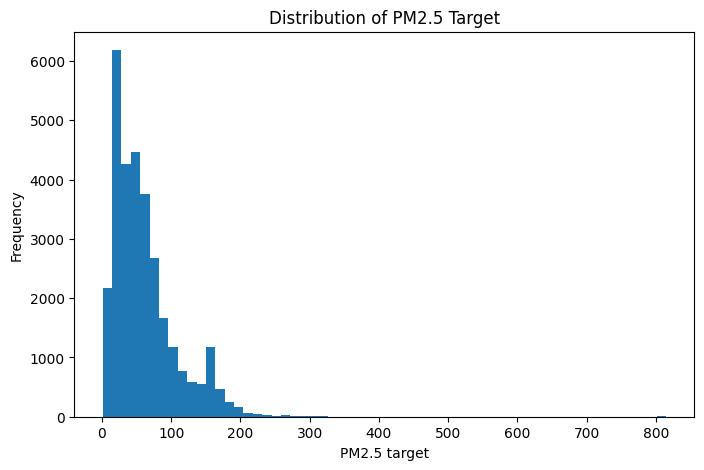

In [79]:
plt.figure(figsize=(8, 5))
plt.hist(train["target"], bins=60)
plt.xlabel("PM2.5 target")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Target")
plt.show()

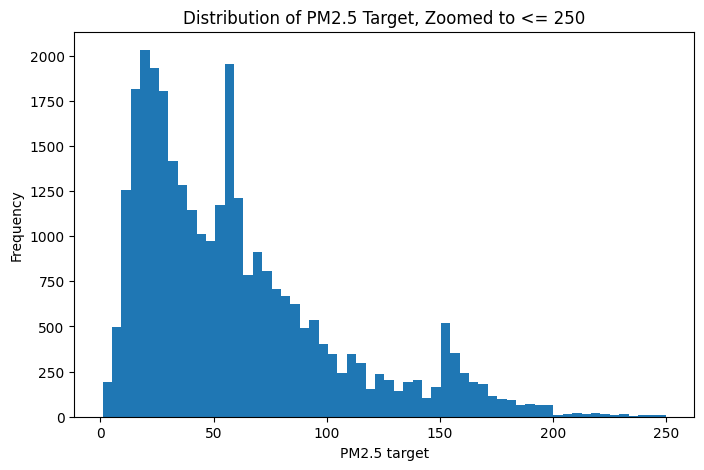

In [80]:
plt.figure(figsize=(8, 5))
plt.hist(train.loc[train["target"] <= 250, "target"], bins=60)
plt.xlabel("PM2.5 target")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Target, Zoomed to <= 250")
plt.show()

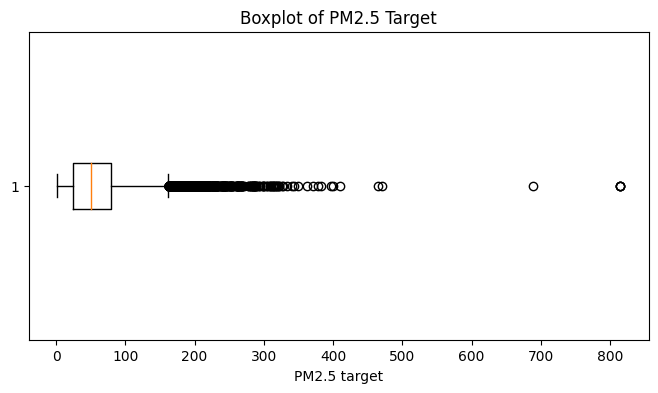

In [81]:
plt.figure(figsize=(8, 4))
plt.boxplot(train["target"], vert=False)
plt.xlabel("PM2.5 target")
plt.title("Boxplot of PM2.5 Target")
plt.show()

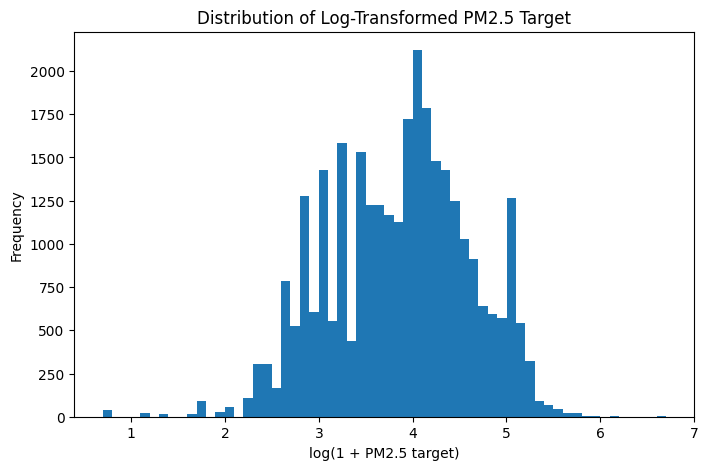

In [82]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train["target"]), bins=60)
plt.xlabel("log(1 + PM2.5 target)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed PM2.5 Target")
plt.show()

The target variable contains 30,557 observations. The mean PM2.5 value is approximately 61.15, while the median is 50.00. Since the mean is higher than the median, the target distribution is right-skewed.

The quantile analysis shows that 95% of the observations are below 158 and 99% are below 198. However, the maximum value is 815, which is far above the 99th percentile. This indicates that the dataset contains a small number of extreme pollution events.

This is important for modeling because the evaluation metric is RMSE. RMSE penalizes large prediction errors strongly, so underpredicting rare high-pollution events can significantly worsen the model score.

For the first baseline model, the original target will be used. Later, a log-transformed target using `log(1 + target)` can be tested to check whether it improves the model performance on this right-skewed distribution.


#### Convert date column

In [83]:
# Convert Date column to datetime format
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Train date range:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest date range:")
print(test["Date"].min(), "to", test["Date"].max())

Train date range:
2020-01-02 00:00:00 to 2020-04-04 00:00:00

Test date range:
2020-01-02 00:00:00 to 2020-04-04 00:00:00


#### PM2.5 Over Time

In [84]:
# Check number of unique dates
print("Number of unique train dates:", train["Date"].nunique())
print("Number of unique test dates:", test["Date"].nunique())

Number of unique train dates: 94
Number of unique test dates: 94


In [85]:
# Aggregate PM2.5 target by date
daily_stats = train.groupby("Date")["target"].agg(
    ["mean", "median", "std", "min", "max", "count"]
)

daily_stats.head()

,mean,median,std,min,max,count
Date,,,,,,
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324
2020-01-03,73.618043,59.0,54.179601,3.0,311.0,327
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329
2020-01-05,64.680060,46.0,63.710470,2.0,689.0,331
2020-01-06,63.621713,54.0,47.568742,4.0,252.0,327


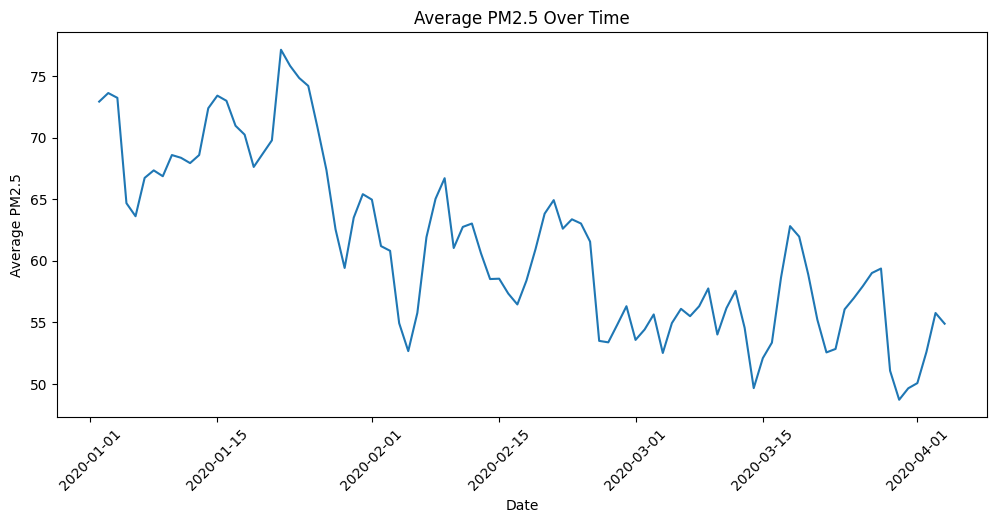

In [86]:
# Average PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["mean"])
plt.xlabel("Date")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Over Time")
plt.xticks(rotation=45)
plt.show()

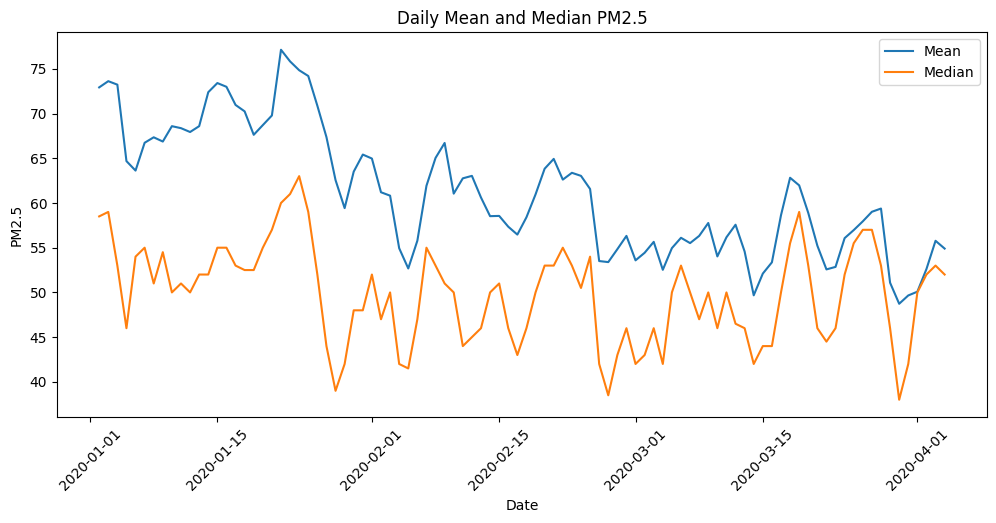

In [87]:
# Mean and median PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["mean"], label="Mean")
plt.plot(daily_stats.index, daily_stats["median"], label="Median")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("Daily Mean and Median PM2.5")
plt.xticks(rotation=45)
plt.legend()
plt.show()

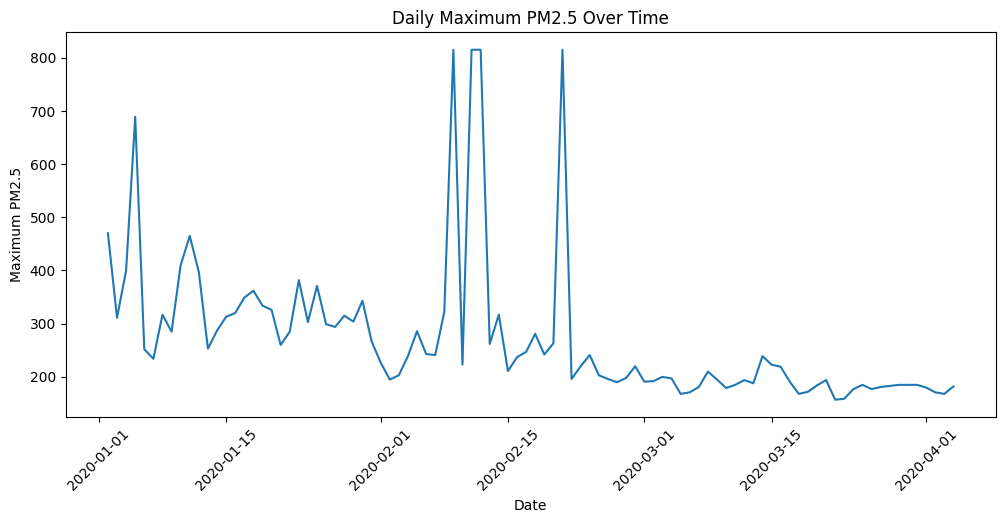

In [88]:
# Daily maximum PM2.5 over time
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["max"])
plt.xlabel("Date")
plt.ylabel("Maximum PM2.5")
plt.title("Daily Maximum PM2.5 Over Time")
plt.xticks(rotation=45)
plt.show()

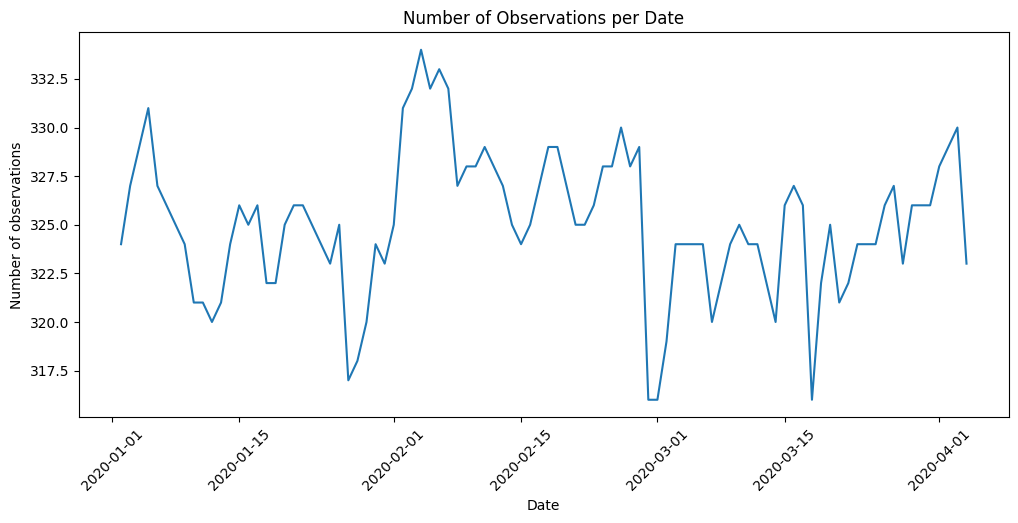

In [89]:
# Number of observations per date
plt.figure(figsize=(12, 5))
plt.plot(daily_stats.index, daily_stats["count"])
plt.xlabel("Date")
plt.ylabel("Number of observations")
plt.title("Number of Observations per Date")
plt.xticks(rotation=45)
plt.show()

In [90]:
# Top 10 days by average PM2.5
daily_stats.sort_values("mean", ascending=False).head(10)

,mean,median,std,min,max,count
Date,,,,,,
2020-01-22,77.130368,60.0,52.033805,5.0,285.0,326
2020-01-23,75.826462,61.0,54.966476,4.0,382.0,325
2020-01-24,74.839506,63.0,51.319855,5.0,303.0,324
2020-01-25,74.196285,59.0,56.577883,5.0,371.0,323
2020-01-03,73.618043,59.0,54.179601,3.0,311.0,327
2020-01-15,73.407669,55.0,57.151826,3.0,313.0,326
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329
2020-01-16,72.988308,55.0,58.666566,3.0,320.0,325
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324


In [91]:
# Top 10 days by maximum PM2.5
daily_stats.sort_values("max", ascending=False).head(10)

,mean,median,std,min,max,count
Date,,,,,,
2020-02-12,63.030488,45.0,63.141598,1.0,815.0,328
2020-02-21,64.929231,53.0,59.829526,1.0,815.0,325
2020-02-09,66.708537,51.0,64.852613,2.0,815.0,328
2020-02-11,62.754407,44.0,62.542425,1.0,815.0,329
2020-01-05,64.680060,46.0,63.710470,2.0,689.0,331
2020-01-02,72.923457,58.5,58.288743,7.0,470.0,324
2020-01-11,68.363863,51.0,58.981736,2.0,465.0,321
2020-01-10,68.587227,50.0,58.635675,1.0,410.0,321
2020-01-04,73.228267,53.0,63.121400,1.0,400.0,329


The time-based analysis shows that average PM2.5 varies noticeably over the observed period. The daily mean is generally higher in January and decreases toward March and early April. This indicates that the `Date` column contains useful temporal information for the prediction task.

The daily mean and median curves show that the mean is often higher than the median. This is consistent with the right-skewed target distribution observed earlier and suggests that some high-pollution observations pull the daily mean upward.

The daily maximum plot reveals several extreme PM2.5 values, especially in February, where the maximum reaches 815 on multiple days. However, the daily mean on these days is not the highest in the dataset. This suggests that these extreme values are likely local events at specific locations rather than city-wide or global pollution peaks across all locations.

The number of observations per date is relatively stable, mostly between about 316 and 334 observations. Therefore, the observed temporal variation is unlikely to be caused only by changes in data coverage.

For modeling, the raw `Date` column will be transformed into numerical time features such as `month`, `dayofweek`, `dayofyear`, `weekofyear`, and cyclic seasonal features.


#### PM2.5 by location


In [92]:
place_stats = train.groupby("Place_ID")["target"].agg(
    ["mean", "median", "std", "min", "max", "count"]
).sort_values("mean", ascending=False)

place_stats.head(10)

,mean,median,std,min,max,count
Place_ID,,,,,,
THZR2TS,200.691489,192.5,44.622919,107.0,343.0,94
JABMGKI,166.989362,170.0,52.471087,55.0,313.0,94
EE8C6RP,158.063830,163.5,32.880628,82.0,257.0,94
WMD80ZE,157.212766,154.0,58.423900,50.0,382.0,94
IM6VR3X,154.542553,165.5,80.323093,30.0,400.0,94
RWKDYP8,151.978723,154.0,62.522594,30.0,309.0,94
KXX7F64,151.531915,155.5,70.514500,34.0,327.0,94
NHB348L,150.521277,159.5,31.419030,59.0,220.0,94
H6JSAYZ,149.180851,160.5,48.716640,46.0,238.0,94


In [93]:
place_stats.tail(10)

,mean,median,std,min,max,count
Place_ID,,,,,,
LKE9VQB,17.317073,15.0,8.635505,6.0,43.0,41
0GBXTHY,16.329787,14.0,7.416037,7.0,41.0,94
C146N8V,16.223404,15.0,7.068261,4.0,41.0,94
1Z0FIHB,16.095745,13.0,8.890093,5.0,50.0,94
FH6B9N5,15.536170,14.9,3.008299,11.4,25.6,94
7DRFQCK,15.119048,14.0,10.074906,5.0,87.0,84
RFQQX9G,14.957447,13.0,7.621299,7.0,43.0,94
1ZBVIMD,12.241758,12.0,4.196138,5.0,22.0,91
SI12552,11.709677,9.0,13.636253,5.0,119.0,93


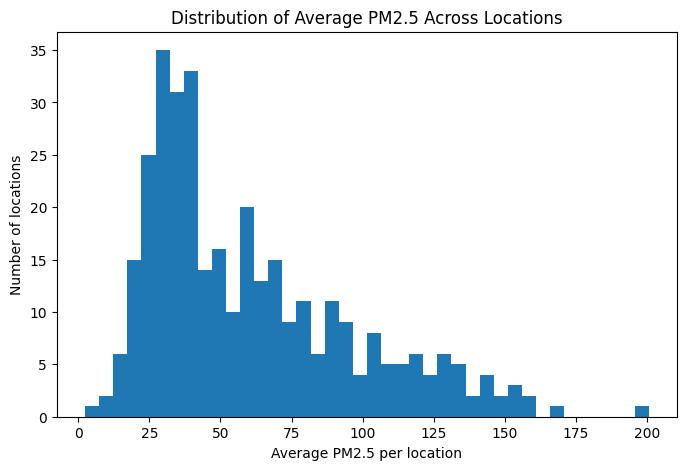

In [94]:
# Distribution of average PM2.5 by location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["mean"], bins=40)
plt.xlabel("Average PM2.5 per location")
plt.ylabel("Number of locations")
plt.title("Distribution of Average PM2.5 Across Locations")
plt.show()

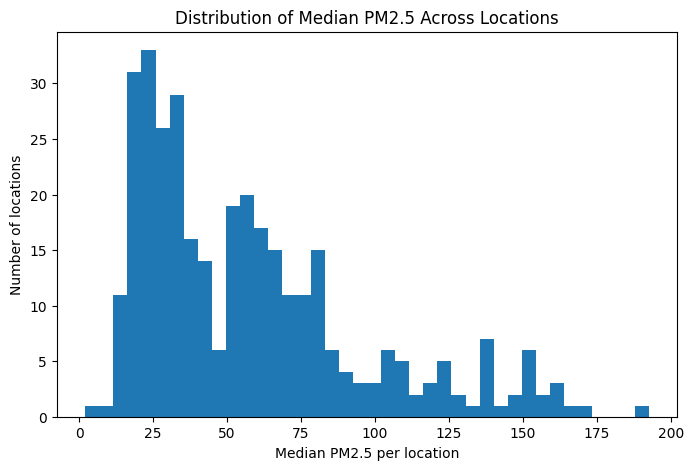

In [95]:
# Distribution of median PM2.5 by location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["median"], bins=40)
plt.xlabel("Median PM2.5 per location")
plt.ylabel("Number of locations")
plt.title("Distribution of Median PM2.5 Across Locations")
plt.show()

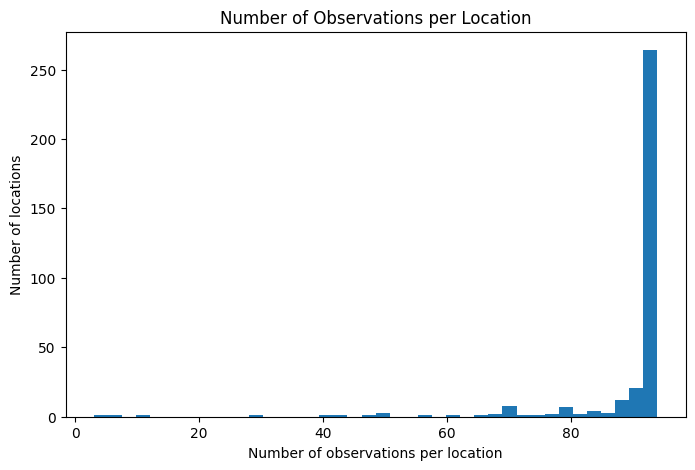

In [96]:
# Number of observations per location
plt.figure(figsize=(8, 5))
plt.hist(place_stats["count"], bins=40)
plt.xlabel("Number of observations per location")
plt.ylabel("Number of locations")
plt.title("Number of Observations per Location")
plt.show()

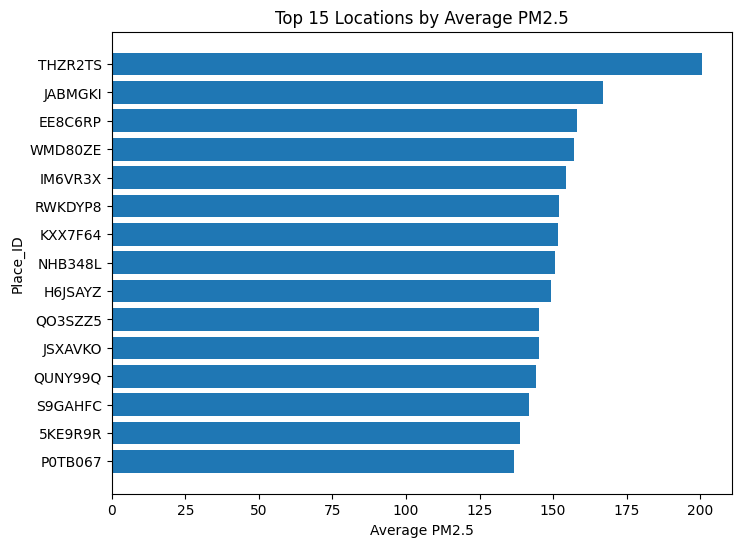

In [97]:
# Top 15 most polluted locations
top_locations = place_stats.head(15).sort_values("mean")

plt.figure(figsize=(8, 6))
plt.barh(top_locations.index, top_locations["mean"])
plt.xlabel("Average PM2.5")
plt.ylabel("Place_ID")
plt.title("Top 15 Locations by Average PM2.5")
plt.show()

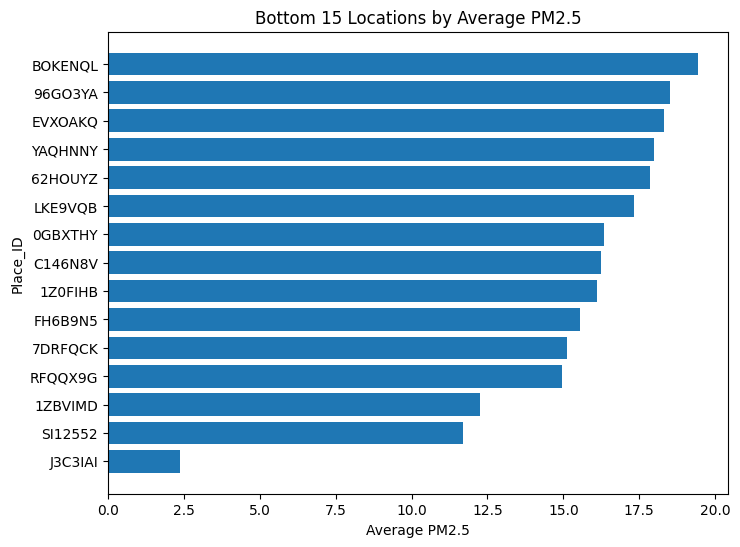

In [98]:
# Bottom 15 least polluted locations
bottom_locations = place_stats.tail(15).sort_values("mean")

plt.figure(figsize=(8, 6))
plt.barh(bottom_locations.index, bottom_locations["mean"])
plt.xlabel("Average PM2.5")
plt.ylabel("Place_ID")
plt.title("Bottom 15 Locations by Average PM2.5")
plt.show()

In [99]:
# Train/test location overlap
train_places = set(train["Place_ID"].unique())
test_places = set(test["Place_ID"].unique())

overlap_places = train_places.intersection(test_places)

print("Number of train locations:", len(train_places))
print("Number of test locations:", len(test_places))
print("Number of overlapping locations:", len(overlap_places))

Number of train locations: 340
Number of test locations: 179
Number of overlapping locations: 0


In [100]:
# Average observations per location
place_stats["count"].describe()

count    340.000000
mean      89.873529
std       11.976324
min        3.000000
25%       92.000000
50%       94.000000
75%       94.000000
max       94.000000
Name: count, dtype: float64

The location-based analysis shows strong spatial variation in PM2.5 levels. Some locations have much higher average PM2.5 concentrations than others, while several locations have consistently low pollution levels. This confirms that air pollution is strongly location-dependent, likely due to differences in traffic, industrial activity, dust, burning sources, local weather, and other environmental conditions.

The distribution of average and median PM2.5 across locations is right-skewed. Most locations have moderate average PM2.5 levels, while a smaller number of locations show very high average pollution. This indicates that some locations are persistent pollution hotspots.

The number of observations per location is mostly high, with many locations having observations for most dates in the dataset. This supports a reliable location-level comparison, although a few locations have fewer observations.

Importantly, the train and test sets have no overlapping `Place_ID`s. The training data contains 340 unique locations, the test data contains 179 unique locations, and the number of overlapping locations is 0. Therefore, raw `Place_ID` should not be used as a direct model feature because the model would learn location-specific patterns that cannot transfer to unseen test locations.

However, `Place_ID` is still very useful for validation. We will use `GroupKFold` with `Place_ID` as the grouping variable to ensure that all observations from the same location stay in the same fold. This gives a more realistic estimate of model performance on unseen locations.


#### Feature relationships with PM2.5

In [101]:
# Create wind speed
train["wind_speed"] = np.sqrt(
    train["u_component_of_wind_10m_above_ground"]**2
    + train["v_component_of_wind_10m_above_ground"]**2
)

test["wind_speed"] = np.sqrt(
    test["u_component_of_wind_10m_above_ground"]**2
    + test["v_component_of_wind_10m_above_ground"]**2
)

In [102]:
# Select key domain features
key_features = [
    "target",
    "precipitable_water_entire_atmosphere",
    "relative_humidity_2m_above_ground",
    "specific_humidity_2m_above_ground",
    "temperature_2m_above_ground",
    "wind_speed",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "L3_NO2_NO2_column_number_density",
    "L3_NO2_tropospheric_NO2_column_number_density",
    "L3_O3_O3_column_number_density",
    "L3_CO_CO_column_number_density",
    "L3_HCHO_tropospheric_HCHO_column_number_density",
    "L3_AER_AI_absorbing_aerosol_index",
    "L3_SO2_SO2_column_number_density",
]

existing_key_features = [col for col in key_features if col in train.columns]

corr_with_target = (
    train[existing_key_features]
    .corr(numeric_only=True)["target"]
    .sort_values(ascending=False)
)

corr_with_target

target                                             1.000000
L3_CO_CO_column_number_density                     0.375737
L3_HCHO_tropospheric_HCHO_column_number_density    0.347125
L3_NO2_NO2_column_number_density                   0.306772
L3_NO2_tropospheric_NO2_column_number_density      0.295380
L3_AER_AI_absorbing_aerosol_index                  0.070795
L3_SO2_SO2_column_number_density                   0.045052
precipitable_water_entire_atmosphere              -0.031329
specific_humidity_2m_above_ground                 -0.035670
temperature_2m_above_ground                       -0.038818
v_component_of_wind_10m_above_ground              -0.055100
relative_humidity_2m_above_ground                 -0.084835
L3_O3_O3_column_number_density                    -0.088099
u_component_of_wind_10m_above_ground              -0.148202
wind_speed                                        -0.341750
Name: target, dtype: float64

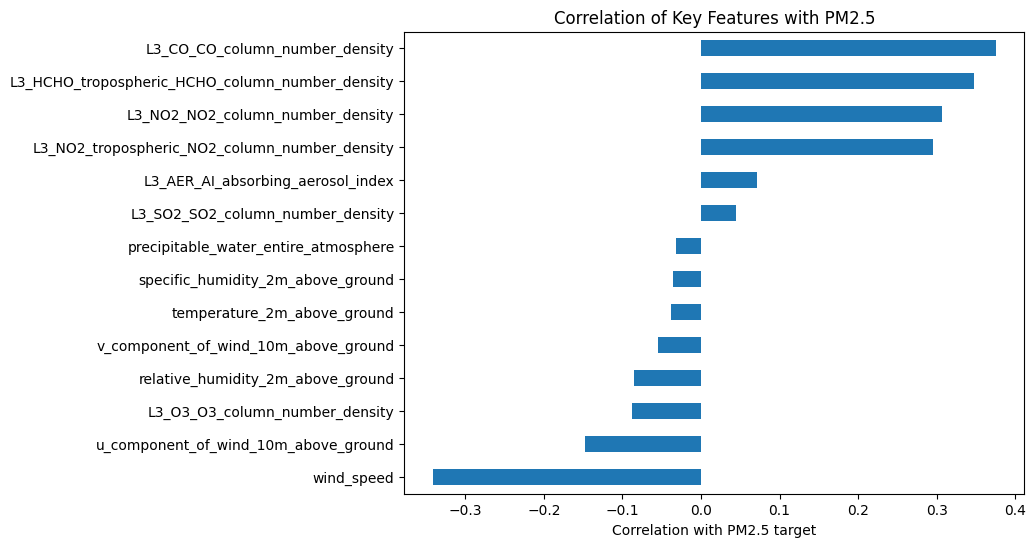

In [103]:
# Plot correlations
plt.figure(figsize=(8, 6))
corr_with_target.drop("target").sort_values().plot(kind="barh")
plt.xlabel("Correlation with PM2.5 target")
plt.title("Correlation of Key Features with PM2.5")
plt.show()

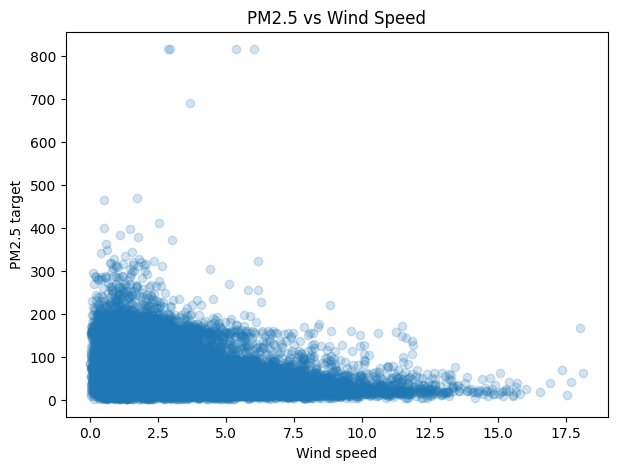

In [104]:
# Scatter: PM2.5 vs wind speed
plt.figure(figsize=(7, 5))
plt.scatter(train["wind_speed"], train["target"], alpha=0.2)
plt.xlabel("Wind speed")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Wind Speed")
plt.show()

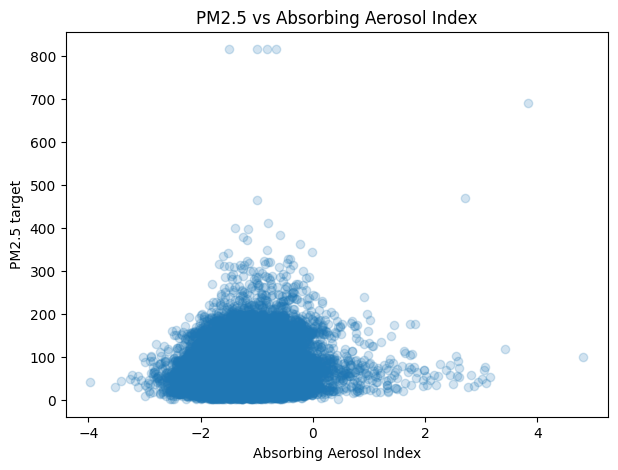

In [105]:
# Scatter: PM2.5 vs aerosol index
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_AER_AI_absorbing_aerosol_index"],
    train["target"],
    alpha=0.2
)
plt.xlabel("Absorbing Aerosol Index")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Absorbing Aerosol Index")
plt.show()

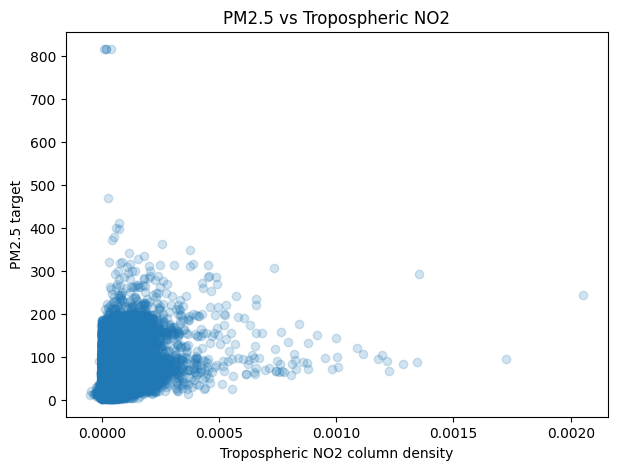

In [106]:
# Scatter: PM2.5 vs NO2 tropospheric column
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_NO2_tropospheric_NO2_column_number_density"],
    train["target"],
    alpha=0.2
)
plt.xlabel("Tropospheric NO2 column density")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs Tropospheric NO2")
plt.show()

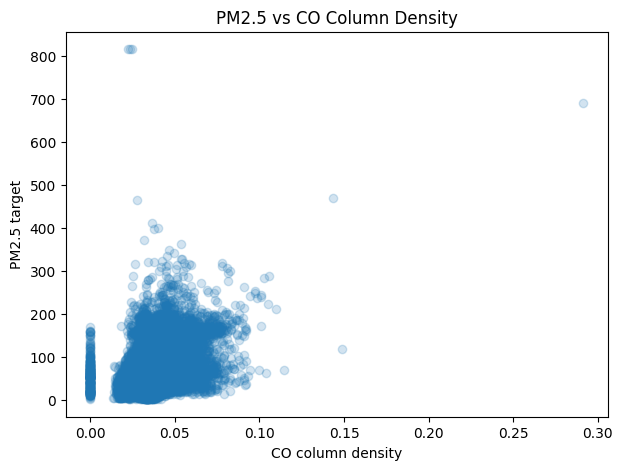

In [107]:
# Scatter: PM2.5 vs CO column
plt.figure(figsize=(7, 5))
plt.scatter(
    train["L3_CO_CO_column_number_density"],
    train["target"],
    alpha=0.2
)
plt.xlabel("CO column density")
plt.ylabel("PM2.5 target")
plt.title("PM2.5 vs CO Column Density")
plt.show()

In [108]:
corr_with_target

target                                             1.000000
L3_CO_CO_column_number_density                     0.375737
L3_HCHO_tropospheric_HCHO_column_number_density    0.347125
L3_NO2_NO2_column_number_density                   0.306772
L3_NO2_tropospheric_NO2_column_number_density      0.295380
L3_AER_AI_absorbing_aerosol_index                  0.070795
L3_SO2_SO2_column_number_density                   0.045052
precipitable_water_entire_atmosphere              -0.031329
specific_humidity_2m_above_ground                 -0.035670
temperature_2m_above_ground                       -0.038818
v_component_of_wind_10m_above_ground              -0.055100
relative_humidity_2m_above_ground                 -0.084835
L3_O3_O3_column_number_density                    -0.088099
u_component_of_wind_10m_above_ground              -0.148202
wind_speed                                        -0.341750
Name: target, dtype: float64

The correlation analysis shows that several satellite pollutant features are positively correlated with PM2.5. The strongest positive correlations are observed for CO column density, tropospheric HCHO column density, and NO₂ column density. This is consistent with the domain understanding that CO, HCHO, and NO₂ are related to combustion, traffic, fires, and atmospheric chemical processes that can contribute to PM2.5 pollution.

Wind speed shows the strongest negative correlation with PM2.5. This is physically reasonable because stronger wind can disperse pollutants and reduce local PM2.5 accumulation. However, the relationship may still be complex because wind can also transport dust or smoke from other regions.

Other features, such as ozone, humidity, temperature, SO₂, and aerosol index, show weaker linear correlations. This does not mean they are useless. Correlation only captures linear relationships, while tree-based models can learn nonlinear effects and interactions between variables. Therefore, the correlation analysis is used for understanding the data, but not as the only criterion for feature selection.

## Feature engineering

In [109]:
# Feature engineering functions
def add_date_features(df):
    """Create date-based features from the Date column."""
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # Cyclic encoding for yearly and monthly seasonality.
    df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df


def add_wind_features(df):
    """Create wind speed and wind direction features."""
    df = df.copy()

    u = df["u_component_of_wind_10m_above_ground"]
    v = df["v_component_of_wind_10m_above_ground"]

    df["wind_speed"] = np.sqrt(u**2 + v**2)
    df["wind_direction"] = np.arctan2(v, u)

    # Cyclic encoding for wind direction.
    df["wind_dir_sin"] = np.sin(df["wind_direction"])
    df["wind_dir_cos"] = np.cos(df["wind_direction"])

    return df


def build_feature_reference(df):
    """Build train-only thresholds so regime flags are reproducible and leakage-aware."""
    reference = {}

    if "wind_speed" in df.columns:
        reference["low_wind_threshold"] = df["wind_speed"].quantile(0.25)
    if "relative_humidity_2m_above_ground" in df.columns:
        reference["high_humidity_threshold"] = df["relative_humidity_2m_above_ground"].quantile(0.75)
    if "temperature_2m_above_ground" in df.columns:
        reference["high_temperature_threshold"] = df["temperature_2m_above_ground"].quantile(0.75)
    if "L3_AER_AI_absorbing_aerosol_index" in df.columns:
        reference["high_aerosol_threshold"] = df["L3_AER_AI_absorbing_aerosol_index"].quantile(0.90)

    return reference


def add_physical_proxy_features(df, reference):
    """Add physically motivated proxy features from the project notes."""
    df = df.copy()

    weather_core = [
        "precipitable_water_entire_atmosphere",
        "relative_humidity_2m_above_ground",
        "specific_humidity_2m_above_ground",
        "temperature_2m_above_ground",
        "u_component_of_wind_10m_above_ground",
        "v_component_of_wind_10m_above_ground",
        "wind_speed",
    ]
    weather_core = [col for col in weather_core if col in df.columns]
    satellite_columns = [col for col in df.columns if col.startswith("L3_")]

    if ENABLE_PHYSICAL_PROXY_FEATURES:
        if "temperature_2m_above_ground" in df.columns:
            df["temp_squared"] = df["temperature_2m_above_ground"] ** 2

        if {"temperature_2m_above_ground", "relative_humidity_2m_above_ground"}.issubset(df.columns):
            df["dryness_proxy"] = (
                df["temperature_2m_above_ground"] /
                (df["relative_humidity_2m_above_ground"] + 1)
            )

        if {"relative_humidity_2m_above_ground", "wind_speed"}.issubset(df.columns):
            df["stagnation_proxy"] = (
                df["relative_humidity_2m_above_ground"] /
                (df["wind_speed"] + 1)
            )

        if {"dryness_proxy", "L3_AER_AI_absorbing_aerosol_index"}.issubset(df.columns):
            df["dust_risk_proxy"] = (
                df["dryness_proxy"] * df["L3_AER_AI_absorbing_aerosol_index"]
            )

        combustion_inputs = [
            col for col in [
                "L3_NO2_tropospheric_NO2_column_number_density",
                "L3_CO_CO_column_number_density",
                "L3_HCHO_tropospheric_HCHO_column_number_density",
            ]
            if col in df.columns
        ]
        if combustion_inputs:
            df["combustion_proxy"] = df[combustion_inputs].sum(axis=1, min_count=1)

        industrial_inputs = [
            col for col in [
                "L3_SO2_SO2_column_number_density",
                "L3_NO2_tropospheric_NO2_column_number_density",
            ]
            if col in df.columns
        ]
        if industrial_inputs:
            df["industrial_proxy"] = df[industrial_inputs].sum(axis=1, min_count=1)

        if {"industrial_proxy", "L3_AER_AI_absorbing_aerosol_index"}.issubset(df.columns):
            df["industrial_aerosol_proxy"] = (
                df["industrial_proxy"] * df["L3_AER_AI_absorbing_aerosol_index"]
            )

    if ENABLE_WEATHER_REGIME_FLAGS:
        if {"wind_speed"}.issubset(df.columns) and "low_wind_threshold" in reference:
            df["low_wind_day"] = (
                df["wind_speed"] <= reference["low_wind_threshold"]
            ).astype(int)

        if {"relative_humidity_2m_above_ground"}.issubset(df.columns) and "high_humidity_threshold" in reference:
            df["humid_day"] = (
                df["relative_humidity_2m_above_ground"] >= reference["high_humidity_threshold"]
            ).astype(int)

        if {"temperature_2m_above_ground"}.issubset(df.columns) and "high_temperature_threshold" in reference:
            df["hot_day"] = (
                df["temperature_2m_above_ground"] >= reference["high_temperature_threshold"]
            ).astype(int)

        if {"L3_AER_AI_absorbing_aerosol_index"}.issubset(df.columns) and "high_aerosol_threshold" in reference:
            df["very_high_aerosol_day"] = (
                df["L3_AER_AI_absorbing_aerosol_index"] >= reference["high_aerosol_threshold"]
            ).astype(int)

        if {"low_wind_day", "humid_day"}.issubset(df.columns):
            df["stagnant_humid_day"] = (
                (df["low_wind_day"] == 1) & (df["humid_day"] == 1)
            ).astype(int)

    if ENABLE_MISSINGNESS_PROXY_FEATURES:
        if weather_core:
            df["missing_weather_count"] = df[weather_core].isna().sum(axis=1)
        if satellite_columns:
            df["missing_satellite_count"] = df[satellite_columns].isna().sum(axis=1)
        if {"missing_weather_count", "missing_satellite_count"}.issubset(df.columns):
            df["missing_total_measurement_count"] = (
                df["missing_weather_count"] + df["missing_satellite_count"]
            )
            df["has_missing_satellite"] = (df["missing_satellite_count"] > 0).astype(int)

    if ENABLE_SATELLITE_RELIABILITY_FEATURES:
        reliability_parts = []
        if "L3_CLOUD_cloud_fraction" in df.columns:
            reliability_parts.append(df["L3_CLOUD_cloud_fraction"])
        for col in [
            "L3_AER_AI_sensor_zenith_angle",
            "L3_AER_AI_solar_zenith_angle",
            "L3_CLOUD_sensor_zenith_angle",
            "L3_CLOUD_solar_zenith_angle",
        ]:
            if col in df.columns:
                reliability_parts.append(df[col].abs() / 90)

        if reliability_parts:
            reliability_frame = pd.concat(reliability_parts, axis=1)
            df["satellite_reliability_risk"] = reliability_frame.sum(axis=1, min_count=1)

    return df


In [110]:
# Apply feature engineering
# Each step is kept separate so the notebook remains easy to explain.
train_fe = add_date_features(train)
train_fe = add_wind_features(train_fe)

# Build thresholds from training data only.
# This keeps regime flags deterministic and avoids peeking at the test distribution.
feature_reference = build_feature_reference(train_fe)
train_fe = add_physical_proxy_features(train_fe, feature_reference)

test_fe = add_date_features(test)
test_fe = add_wind_features(test_fe)
test_fe = add_physical_proxy_features(test_fe, feature_reference)

print("Train shape after feature engineering:", train_fe.shape)
print("Test shape after feature engineering:", test_fe.shape)
print("Feature reference thresholds:")
feature_reference


Train shape after feature engineering: (30557, 113)
Test shape after feature engineering: (16136, 108)
Feature reference thresholds:


{'low_wind_threshold': 1.4975624576357573,
 'high_humidity_threshold': 85.45000076293947,
 'high_temperature_threshold': 16.201562500000026,
 'high_aerosol_threshold': -0.5286850513197155}

## Feature selection for the first modeling dataset

In [111]:
# Feature groups
# The notebook keeps raw environmental variables and adds physically motivated proxy features.
weather_features = [
    "precipitable_water_entire_atmosphere",
    "relative_humidity_2m_above_ground",
    "specific_humidity_2m_above_ground",
    "temperature_2m_above_ground",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "wind_speed",
    "wind_dir_sin",
    "wind_dir_cos",
]

date_features = [
    "month",
    "day",
    "dayofweek",
    "dayofyear",
    "weekofyear",
    "is_weekend",
    "dayofyear_sin",
    "dayofyear_cos",
    "month_sin",
    "month_cos",
]

pollutant_features = [
    "L3_NO2_NO2_column_number_density",
    "L3_NO2_tropospheric_NO2_column_number_density",
    "L3_NO2_absorbing_aerosol_index",
    "L3_O3_O3_column_number_density",
    "L3_CO_CO_column_number_density",
    "L3_CO_H2O_column_number_density",
    "L3_HCHO_tropospheric_HCHO_column_number_density",
    "L3_AER_AI_absorbing_aerosol_index",
    "L3_SO2_SO2_column_number_density",
    "L3_SO2_absorbing_aerosol_index",
]

cloud_features = [
    "L3_NO2_cloud_fraction",
    "L3_O3_cloud_fraction",
    "L3_HCHO_cloud_fraction",
    "L3_SO2_cloud_fraction",
    "L3_CLOUD_cloud_base_height",
    "L3_CLOUD_cloud_base_pressure",
    "L3_CLOUD_cloud_fraction",
    "L3_CLOUD_cloud_optical_depth",
    "L3_CLOUD_cloud_top_height",
    "L3_CLOUD_cloud_top_pressure",
    "L3_CLOUD_surface_albedo",
]

quality_features = [
    "L3_AER_AI_sensor_zenith_angle",
    "L3_AER_AI_solar_zenith_angle",
    "L3_CLOUD_sensor_zenith_angle",
    "L3_CLOUD_solar_zenith_angle",
]

engineered_proxy_features = [
    "temp_squared",
    "dryness_proxy",
    "stagnation_proxy",
    "dust_risk_proxy",
    "combustion_proxy",
    "industrial_proxy",
    "industrial_aerosol_proxy",
    "satellite_reliability_risk",
]

regime_flag_features = [
    "low_wind_day",
    "humid_day",
    "hot_day",
    "very_high_aerosol_day",
    "stagnant_humid_day",
]

missingness_features = [
    "missing_weather_count",
    "missing_satellite_count",
    "missing_total_measurement_count",
    "has_missing_satellite",
]

feature_group_map = {
    "weather": (ENABLE_WEATHER_FEATURES, weather_features),
    "date": (ENABLE_DATE_FEATURES, date_features),
    "pollutant": (ENABLE_POLLUTANT_FEATURES, pollutant_features),
    "cloud": (ENABLE_CLOUD_FEATURES, cloud_features),
    "quality": (ENABLE_QUALITY_FEATURES, quality_features),
    "proxy": (ENABLE_PHYSICAL_PROXY_FEATURES, engineered_proxy_features),
    "regime_flags": (ENABLE_WEATHER_REGIME_FLAGS, regime_flag_features),
    "missingness": (ENABLE_MISSINGNESS_PROXY_FEATURES, missingness_features),
}

candidate_features = []
active_feature_groups = []
for group_name, (enabled, group_features) in feature_group_map.items():
    if enabled:
        candidate_features.extend(group_features)
        active_feature_groups.append(group_name)

print("Active feature groups:", active_feature_groups)


Active feature groups: ['weather', 'date', 'pollutant', 'cloud', 'quality', 'proxy', 'regime_flags', 'missingness']


In [112]:
# Keep only existing columns
candidate_features = [col for col in candidate_features if col in train_fe.columns]

print("Number of candidate features:", len(candidate_features))
candidate_features

Number of candidate features: 61


['precipitable_water_entire_atmosphere',
 'relative_humidity_2m_above_ground',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'wind_speed',
 'wind_dir_sin',
 'wind_dir_cos',
 'month',
 'day',
 'dayofweek',
 'dayofyear',
 'weekofyear',
 'is_weekend',
 'dayofyear_sin',
 'dayofyear_cos',
 'month_sin',
 'month_cos',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_tropospheric_NO2_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_O3_O3_column_number_density',
 'L3_CO_CO_column_number_density',
 'L3_CO_H2O_column_number_density',
 'L3_HCHO_tropospheric_HCHO_column_number_density',
 'L3_AER_AI_absorbing_aerosol_index',
 'L3_SO2_SO2_column_number_density',
 'L3_SO2_absorbing_aerosol_index',
 'L3_NO2_cloud_fraction',
 'L3_O3_cloud_fraction',
 'L3_HCHO_cloud_fraction',
 'L3_SO2_cloud_fraction',
 'L3_CLOUD_cloud_base_height',
 'L3_CLOUD_cloud_base_pressure',
 'L3_CLOUD_cloud_fract

In [113]:
# Remove very high-missing columns for models that require classic imputation.
# This defines the baseline feature set used by Ridge, RandomForest, ExtraTrees and the
# imputed HistGradientBoosting pipelines.
missing_ratio = train_fe[candidate_features].isna().mean().sort_values(ascending=False)

high_missing_features = missing_ratio[missing_ratio >= BASELINE_HIGH_MISSING_THRESHOLD].index.tolist()
baseline_features = missing_ratio[missing_ratio < BASELINE_HIGH_MISSING_THRESHOLD].index.tolist()

# Native-missing models can use the full engineered feature set if we want to test whether
# sparse columns still contain useful signal.
if USE_FULL_FEATURE_SET_FOR_NATIVE_MISSING_MODELS:
    native_missing_features = candidate_features.copy()
else:
    native_missing_features = baseline_features.copy()

# Keep the original variable name for the classic baseline pipeline section below.
features = baseline_features

print("Dropped high-missing features for baseline/imputed models:")
print(high_missing_features)
print()
print("Number of baseline features:", len(baseline_features))
print("Number of native-missing features:", len(native_missing_features))
features


Dropped high-missing features for baseline/imputed models:
[]

Number of baseline features: 61
Number of native-missing features: 61


['L3_NO2_tropospheric_NO2_column_number_density',
 'L3_HCHO_tropospheric_HCHO_column_number_density',
 'L3_HCHO_cloud_fraction',
 'L3_SO2_absorbing_aerosol_index',
 'L3_SO2_cloud_fraction',
 'L3_SO2_SO2_column_number_density',
 'industrial_aerosol_proxy',
 'industrial_proxy',
 'L3_CO_CO_column_number_density',
 'L3_CO_H2O_column_number_density',
 'combustion_proxy',
 'L3_NO2_cloud_fraction',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_CLOUD_cloud_base_pressure',
 'L3_CLOUD_cloud_base_height',
 'L3_CLOUD_cloud_optical_depth',
 'L3_CLOUD_cloud_top_height',
 'L3_CLOUD_cloud_top_pressure',
 'L3_CLOUD_surface_albedo',
 'L3_CLOUD_cloud_fraction',
 'L3_CLOUD_sensor_zenith_angle',
 'L3_CLOUD_solar_zenith_angle',
 'L3_O3_cloud_fraction',
 'L3_O3_O3_column_number_density',
 'dust_risk_proxy',
 'L3_AER_AI_solar_zenith_angle',
 'satellite_reliability_risk',
 'L3_AER_AI_sensor_zenith_angle',
 'L3_AER_AI_absorbing_aerosol_index',
 'stagnation_proxy',
 'dryness_proxy'

In [114]:
# Define shared target and grouping information once.
y = train_fe["target"].copy()
groups = train_fe["Place_ID"].copy()

# Baseline/imputed feature matrices.
X = train_fe[baseline_features].copy()
X_test = test_fe[baseline_features].copy()

# Native-missing feature matrices.
# HistGradientBoosting, LightGBM and XGBoost can use these directly without dropping sparse columns.
X_native = train_fe[native_missing_features].copy()
X_test_native = test_fe[native_missing_features].copy()

print("Baseline X shape:", X.shape)
print("Target shape:", y.shape)
print("Baseline X_test shape:", X_test.shape)
print("Native-missing X shape:", X_native.shape)
print("Native-missing X_test shape:", X_test_native.shape)


Baseline X shape: (30557, 61)
Target shape: (30557,)
Baseline X_test shape: (16136, 61)
Native-missing X shape: (30557, 61)
Native-missing X_test shape: (16136, 61)


In [115]:
# Check missingness after baseline feature filtering.
final_missing = X.isna().mean().sort_values(ascending=False)
print("Top baseline-feature missing ratios:")
display(final_missing.head(20))

# Check what the native-missing models will still receive.
native_missing_profile = X_native.isna().mean().sort_values(ascending=False)
print("Top native-missing-feature ratios:")
native_missing_profile.head(20)


Top baseline-feature missing ratios:


L3_NO2_tropospheric_NO2_column_number_density      0.283699
L3_HCHO_cloud_fraction                             0.242989
L3_HCHO_tropospheric_HCHO_column_number_density    0.242989
L3_SO2_absorbing_aerosol_index                     0.239160
L3_SO2_cloud_fraction                              0.236836
L3_SO2_SO2_column_number_density                   0.236836
industrial_aerosol_proxy                           0.196027
industrial_proxy                                   0.190726
L3_CO_CO_column_number_density                     0.177472
L3_CO_H2O_column_number_density                    0.177472
combustion_proxy                                   0.105639
L3_NO2_cloud_fraction                              0.071637
L3_NO2_absorbing_aerosol_index                     0.071637
L3_NO2_NO2_column_number_density                   0.071637
L3_CLOUD_cloud_base_pressure                       0.049809
L3_CLOUD_cloud_base_height                         0.049809
L3_CLOUD_cloud_optical_depth            

Top native-missing-feature ratios:


L3_NO2_tropospheric_NO2_column_number_density      0.283699
L3_HCHO_tropospheric_HCHO_column_number_density    0.242989
L3_HCHO_cloud_fraction                             0.242989
L3_SO2_absorbing_aerosol_index                     0.239160
L3_SO2_cloud_fraction                              0.236836
L3_SO2_SO2_column_number_density                   0.236836
industrial_aerosol_proxy                           0.196027
industrial_proxy                                   0.190726
L3_CO_CO_column_number_density                     0.177472
L3_CO_H2O_column_number_density                    0.177472
combustion_proxy                                   0.105639
L3_NO2_cloud_fraction                              0.071637
L3_NO2_NO2_column_number_density                   0.071637
L3_NO2_absorbing_aerosol_index                     0.071637
L3_CLOUD_cloud_base_pressure                       0.049809
L3_CLOUD_cloud_base_height                         0.049809
L3_CLOUD_cloud_optical_depth            

#### Optional feature-group ablation

This block is off by default because it adds runtime. It tests whether removing whole feature groups helps or hurts the current LightGBM-style signal.


In [116]:
def run_feature_group_ablation(train_df, y, groups, feature_group_map, n_splits=5):
    """Evaluate how much each active feature group contributes."""
    active_groups = [name for name, (enabled, _) in feature_group_map.items() if enabled]
    results = []

    base_model = LGBMRegressor(
        n_estimators=250 if ABLATION_USE_FAST_MODEL else 700,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.01,
        reg_lambda=0.01,
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=CPU_TRAIN_JOBS,
        verbose=-1,
        device_type=LIGHTGBM_DEVICE_TYPE,
    )

    base_features = train_df.columns.tolist()
    base_scores = cross_validate_model(
        model=Pipeline(steps=[("model", clone(base_model))]),
        X=train_df[base_features],
        y=y,
        groups=groups,
        n_splits=n_splits,
    )
    baseline_rmse = float(np.mean(base_scores))
    results.append({"ablation": "all_active_groups", "mean_rmse": baseline_rmse, "delta_vs_baseline": 0.0})

    for group_name in active_groups:
        group_features = [col for col in feature_group_map[group_name][1] if col in train_df.columns]
        reduced_features = [col for col in base_features if col not in group_features]
        if not reduced_features:
            continue

        scores = cross_validate_model(
            model=Pipeline(steps=[("model", clone(base_model))]),
            X=train_df[reduced_features],
            y=y,
            groups=groups,
            n_splits=n_splits,
        )
        mean_rmse = float(np.mean(scores))
        results.append({
            "ablation": f"drop_{group_name}",
            "mean_rmse": mean_rmse,
            "delta_vs_baseline": mean_rmse - baseline_rmse,
        })

    return pd.DataFrame(results).sort_values(["mean_rmse", "ablation"]).reset_index(drop=True)


if RUN_FEATURE_GROUP_ABLATION:
    ablation_results_df = run_feature_group_ablation(
        train_df=X_native,
        y=y,
        groups=groups,
        feature_group_map=feature_group_map,
        n_splits=CV_N_SPLITS,
    )
    display(ablation_results_df)
else:
    print("Feature-group ablation skipped. Set RUN_FEATURE_GROUP_ABLATION = True to run it.")


Feature-group ablation skipped. Set RUN_FEATURE_GROUP_ABLATION = True to run it.


In [117]:
print("Number of final features:", len(features))
final_missing.head(20)


Number of final features: 61


L3_NO2_tropospheric_NO2_column_number_density      0.283699
L3_HCHO_cloud_fraction                             0.242989
L3_HCHO_tropospheric_HCHO_column_number_density    0.242989
L3_SO2_absorbing_aerosol_index                     0.239160
L3_SO2_cloud_fraction                              0.236836
L3_SO2_SO2_column_number_density                   0.236836
industrial_aerosol_proxy                           0.196027
industrial_proxy                                   0.190726
L3_CO_CO_column_number_density                     0.177472
L3_CO_H2O_column_number_density                    0.177472
combustion_proxy                                   0.105639
L3_NO2_cloud_fraction                              0.071637
L3_NO2_absorbing_aerosol_index                     0.071637
L3_NO2_NO2_column_number_density                   0.071637
L3_CLOUD_cloud_base_pressure                       0.049809
L3_CLOUD_cloud_base_height                         0.049809
L3_CLOUD_cloud_optical_depth            

After feature engineering and initial feature selection, the first modeling dataset contains 38 features. These include weather variables, engineered wind features, date-derived features, satellite pollutant features, aerosol indicators, and cloud-context features.

Some satellite features still contain missing values. The highest missingness is observed for the tropospheric NO₂ column density, HCHO-related features, and SO₂-related features. However, the missingness is below the 80% threshold used for feature removal. Therefore, these features are kept in the first modeling dataset.

Missing values will be handled using median imputation inside the preprocessing pipeline. Median imputation is chosen because it is simple, robust to outliers, and suitable for numerical tabular features.

## Missing value handling strategy

#### Define RMSE function

In [118]:
def rmse(y_true, y_pred):
    """Calculate root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

#### Define X, y, and groups

In [119]:
X = train_fe[features]
y = train_fe["target"]
groups = train_fe["Place_ID"]

X_test = test_fe[features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (30557, 61)
y shape: (30557,)
X_test shape: (16136, 61)


#### Preprocessing pipelines

In [120]:
numeric_features = baseline_features
numeric_features_native = native_missing_features

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features,
        )
    ]
)


In [121]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ]
)

In [122]:
def cross_validate_model(model, X, y, groups, n_splits=CV_N_SPLITS):
    """
    Evaluate a model using GroupKFold cross-validation.

    GroupKFold ensures that all rows from the same Place_ID
    stay together in either training or validation.
    """
    cv = GroupKFold(n_splits=n_splits)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups=groups),
        start=1
    ):
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        fold_rmse = rmse(y_val, preds)
        scores.append(fold_rmse)

        print(f"Fold {fold}: RMSE = {fold_rmse:.4f}")

    print("-" * 40)
    print(f"Mean RMSE: {np.mean(scores):.4f}")
    print(f"Std RMSE:  {np.std(scores):.4f}")

    return scores


## Define baseline models

#### Model pipelines

In [123]:
dummy_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

ridge_pipe = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=RF_N_ESTIMATORS,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=CPU_TRAIN_JOBS,
            ),
        ),
    ]
)

hgb_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)


Four models are evaluated using GroupKFold cross-validation with `Place_ID` as the grouping variable.

The models are:

1. Dummy Regressor — predicts the mean target value and serves as a minimum baseline.
2. Ridge Regression — a regularized linear model.
3. Random Forest Regressor — a nonlinear ensemble model based on bagging.
4. HistGradientBoosting Regressor — a gradient boosting model for tabular data.

GroupKFold is used because the test set contains locations that are not present in the training set. This validation strategy estimates how well the model generalizes to unseen locations.

#### Run model comparison

In [124]:
models = {
    "Dummy Mean": dummy_pipe,
    "Ridge Regression": ridge_pipe,
    "Random Forest": rf_pipe,
    "HistGradientBoosting": hgb_pipe,
}

results = []

for name, model in models.items():
    print(f"\n{name}")
    print("=" * len(name))

    scores = cross_validate_model(
        model=model,
        X=X,
        y=y,
        groups=groups,
        n_splits=5,
    )

    results.append(
        {
            "model": name,
            "mean_rmse": np.mean(scores),
            "std_rmse": np.std(scores),
        }
    )

results_df = pd.DataFrame(results).sort_values("mean_rmse")
results_df


Dummy Mean
Fold 1: RMSE = 51.5290
Fold 2: RMSE = 46.9687
Fold 3: RMSE = 42.1294
Fold 4: RMSE = 49.3347
Fold 5: RMSE = 44.1746
----------------------------------------
Mean RMSE: 46.8273
Std RMSE:  3.3917

Ridge Regression
Fold 1: RMSE = 40.6152
Fold 2: RMSE = 39.4623
Fold 3: RMSE = 32.2590
Fold 4: RMSE = 40.9046
Fold 5: RMSE = 34.4796
----------------------------------------
Mean RMSE: 37.5441
Std RMSE:  3.5136

Random Forest
Fold 1: RMSE = 36.3645
Fold 2: RMSE = 34.6107
Fold 3: RMSE = 29.2459
Fold 4: RMSE = 38.6580
Fold 5: RMSE = 31.6884
----------------------------------------
Mean RMSE: 34.1135
Std RMSE:  3.3329

HistGradientBoosting
Fold 1: RMSE = 35.2033
Fold 2: RMSE = 33.8652
Fold 3: RMSE = 28.7818
Fold 4: RMSE = 38.1979
Fold 5: RMSE = 30.5511
----------------------------------------
Mean RMSE: 33.3199
Std RMSE:  3.3437


,model,mean_rmse,std_rmse
3,HistGradientBoosting,33.319869,3.343657
2,Random Forest,34.113491,3.332880
1,Ridge Regression,37.544135,3.513616
0,Dummy Mean,46.827269,3.391746


#### Plot model comparison

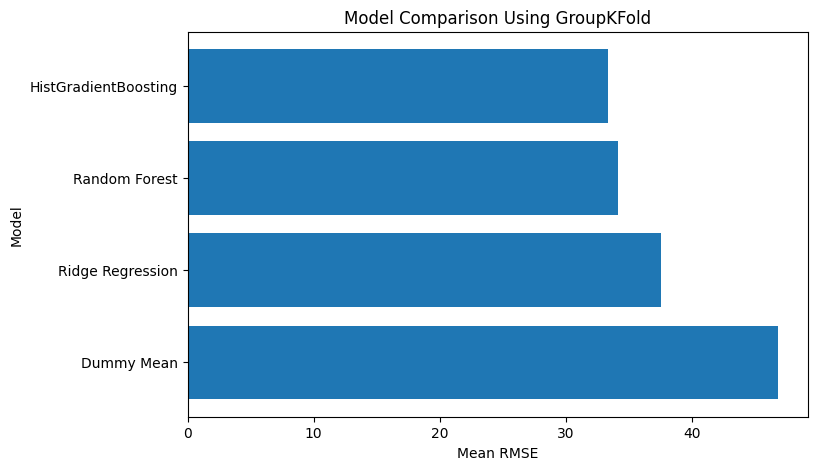

In [125]:
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Model Comparison Using GroupKFold")
plt.gca().invert_yaxis()
plt.show()

The baseline model comparison shows that all machine-learning models perform better than the dummy mean predictor. The Dummy Regressor achieves a mean RMSE of 46.83, which represents the performance of simply predicting the average PM2.5 value for every observation.

Ridge Regression improves the RMSE to 38.56, showing that the selected features contain useful predictive information. However, the nonlinear ensemble models perform substantially better. Random Forest achieves a mean RMSE of 34.55, while HistGradientBoosting achieves the best baseline score with a mean RMSE of 34.30.

This indicates that the relationship between weather, satellite pollutant features, date features, and PM2.5 is likely nonlinear. The best baseline model, HistGradientBoosting, improves the RMSE by approximately 27% compared with the Dummy Regressor.

Since HistGradientBoosting gives the lowest mean RMSE, it is selected as the main candidate for hyperparameter tuning. Random Forest is kept as a strong alternative because its performance is very close.

## Hyperparameter tuning of HistGradientBoosting

In [126]:
# HistGradientBoosting tuning still uses the baseline/imputed feature matrix on purpose.
# This makes the search directly comparable to the earlier imputed HGB baseline.
hgb_tuning_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_distributions = {
    "model__learning_rate": [0.02, 0.03, 0.05, 0.07, 0.10],
    "model__max_iter": [200, 300, 500, 700],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

cv = GroupKFold(n_splits=CV_N_SPLITS)

hgb_search = RandomizedSearchCV(
    estimator=hgb_tuning_pipe,
    param_distributions=param_distributions,
    n_iter=HGB_RANDOM_SEARCH_ITERATIONS,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)

hgb_search.fit(X, y, groups=groups)

print("Best RMSE:", -hgb_search.best_score_)
print("Best parameters:")
hgb_search.best_params_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RMSE: 32.65554704020212
Best parameters:


{'model__min_samples_leaf': 30,
 'model__max_leaf_nodes': 63,
 'model__max_iter': 700,
 'model__learning_rate': 0.03,
 'model__l2_regularization': 0.01}

In [127]:
print("Best RMSE:", -hgb_search.best_score_)
hgb_search.best_params_

Best RMSE: 32.65554704020212


{'model__min_samples_leaf': 30,
 'model__max_leaf_nodes': 63,
 'model__max_iter': 700,
 'model__learning_rate': 0.03,
 'model__l2_regularization': 0.01}

The best hyperparameters found for the HistGradientBoosting model use a relatively small learning rate of 0.03 together with a high number of boosting iterations, 700. This means the model learns gradually by adding many small corrections.

The maximum number of leaf nodes is 63, which allows each tree to model more complex nonlinear relationships. At the same time, `min_samples_leaf = 30` prevents the trees from creating very small leaves that may overfit individual observations. A small L2 regularization value of 0.01 is also used to improve generalization.

Overall, the tuned model is more flexible than the initial baseline HistGradientBoosting model, but it still includes regularization to reduce overfitting.


#### Comparison with the HistGradientBoosting base-line model

In [128]:
print("Baseline HistGradientBoosting RMSE:", results_df.loc[
    results_df["model"] == "HistGradientBoosting", "mean_rmse"
].values[0])

print("Tuned HistGradientBoosting RMSE:", -hgb_search.best_score_)

Baseline HistGradientBoosting RMSE: 33.31986878377553
Tuned HistGradientBoosting RMSE: 32.65554704020212


In [129]:
baseline_hgb_rmse = results_df.loc[
    results_df["model"] == "HistGradientBoosting", "mean_rmse"
].values[0]

tuned_hgb_rmse = -hgb_search.best_score_

improvement = baseline_hgb_rmse - tuned_hgb_rmse
improvement_percent = improvement / baseline_hgb_rmse * 100

print(f"Improvement in RMSE: {improvement:.4f}")
print(f"Improvement percentage: {improvement_percent:.2f}%")

Improvement in RMSE: 0.6643
Improvement percentage: 1.99%


#### Tuned final HGB pipeline

In [130]:
# Use the actual best estimator from the search instead of copying old parameter values manually.
if "hgb_search" not in globals() or not hasattr(hgb_search, "best_estimator_"):
    raise RuntimeError("Run the HistGradientBoosting tuning cell before building the tuned pipeline.")

tuned_hgb_pipe = clone(hgb_search.best_estimator_)


Hyperparameter tuning improved the HistGradientBoosting model. The baseline HistGradientBoosting model achieved a mean GroupKFold RMSE of 34.30, while the tuned model achieved a mean RMSE of 33.68.

This corresponds to an improvement of approximately 0.62 RMSE points, or about 1.8%. The improvement is moderate, but meaningful, because the baseline HistGradientBoosting model was already the strongest initial model.

The tuned HistGradientBoosting model is therefore selected as the current best model. It will be used as the main candidate for final training and test-set prediction, unless further experiments such as missingness indicators or log-target transformation improve the validation score.


#### Updated results table

In [131]:
tuned_result = pd.DataFrame(
    [
        {
            "model": "Tuned HistGradientBoosting",
            "mean_rmse": -hgb_search.best_score_,
            "std_rmse": np.nan,
        }
    ]
)

results_with_tuned_df = pd.concat(
    [results_df, tuned_result],
    ignore_index=True
).sort_values("mean_rmse")

results_with_tuned_df

,model,mean_rmse,std_rmse
4,Tuned HistGradientBoosting,32.655547,NaN
0,HistGradientBoosting,33.319869,3.343657
1,Random Forest,34.113491,3.332880
2,Ridge Regression,37.544135,3.513616
3,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

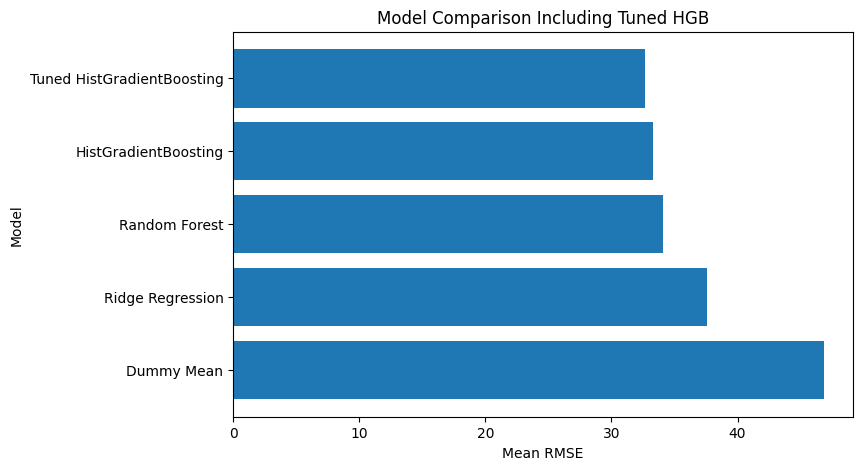

In [132]:
plt.figure(figsize=(8, 5))
plt.barh(results_with_tuned_df["model"], results_with_tuned_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Model Comparison Including Tuned HGB")
plt.gca().invert_yaxis()
plt.show()

## Tests 

#### Missingness indicators

In [133]:
# Use the same baseline feature set as the imputed HGB pipeline, but add explicit missingness indicators.
tree_preprocessor_missing = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            ),
            numeric_features,
        )
    ]
)


In [134]:
tuned_hgb_missing_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor_missing),
        (
            "model",
            HistGradientBoostingRegressor(
                min_samples_leaf=30,
                max_leaf_nodes=63,
                max_iter=700,
                learning_rate=0.03,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [135]:
# Evaluate it
print("Tuned HGB with missingness indicators")
print("=" * 43)

hgb_missing_scores = cross_validate_model(
    model=tuned_hgb_missing_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

hgb_missing_mean_rmse = np.mean(hgb_missing_scores)
hgb_missing_std_rmse = np.std(hgb_missing_scores)

print(f"Mean RMSE: {hgb_missing_mean_rmse:.4f}")
print(f"Std RMSE:  {hgb_missing_std_rmse:.4f}")

Tuned HGB with missingness indicators
Fold 1: RMSE = 34.4177
Fold 2: RMSE = 32.9830
Fold 3: RMSE = 28.2742
Fold 4: RMSE = 37.7310
Fold 5: RMSE = 29.8241
----------------------------------------
Mean RMSE: 32.6460
Std RMSE:  3.3522
Mean RMSE: 32.6460
Std RMSE:  3.3522


In [136]:
# Compare
print(f"Current best tuned HGB RMSE:       {tuned_hgb_rmse:.4f}")
print(f"HGB + missing indicators RMSE:     {hgb_missing_mean_rmse:.4f}")

difference = tuned_hgb_rmse - hgb_missing_mean_rmse
difference_percent = difference / tuned_hgb_rmse * 100

print(f"Difference in RMSE: {difference:.4f}")
print(f"Difference percentage: {difference_percent:.2f}%")

Current best tuned HGB RMSE:       32.6555
HGB + missing indicators RMSE:     32.6460
Difference in RMSE: 0.0095
Difference percentage: 0.03%


Adding missingness indicators slightly improved the tuned HistGradientBoosting model. The RMSE decreased from 33.68 to 33.61, corresponding to an improvement of approximately 0.08 RMSE points or 0.23%.

The improvement is small, but it suggests that missing values in the satellite features may contain some useful information. This is plausible because missing satellite measurements can be related to cloud cover, retrieval quality, or atmospheric conditions.

Since this experiment achieved the lowest validation RMSE so far, the pipeline with missingness indicators is kept for the next experiment.

#### Log target

In [137]:
best_hgb_pipe = tuned_hgb_missing_pipe
best_rmse_before_log = hgb_missing_mean_rmse

print("Best pipeline before log target: Tuned HGB + missingness indicators")
print(f"Best RMSE before log target: {best_rmse_before_log:.4f}")

Best pipeline before log target: Tuned HGB + missingness indicators
Best RMSE before log target: 32.6460


In [138]:
from sklearn.compose import TransformedTargetRegressor

log_best_hgb_pipe = TransformedTargetRegressor(
    regressor=best_hgb_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

In [139]:
# Evaluate
print("Tuned HGB + missingness indicators + log target")
print("=" * 52)

log_best_hgb_scores = cross_validate_model(
    model=log_best_hgb_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

log_best_hgb_mean_rmse = np.mean(log_best_hgb_scores)
log_best_hgb_std_rmse = np.std(log_best_hgb_scores)

print(f"Mean RMSE: {log_best_hgb_mean_rmse:.4f}")
print(f"Std RMSE:  {log_best_hgb_std_rmse:.4f}")

Tuned HGB + missingness indicators + log target
Fold 1: RMSE = 36.8510
Fold 2: RMSE = 35.5517
Fold 3: RMSE = 28.6685
Fold 4: RMSE = 38.9003
Fold 5: RMSE = 30.0146
----------------------------------------
Mean RMSE: 33.9972
Std RMSE:  3.9713
Mean RMSE: 33.9972
Std RMSE:  3.9713


A log-transformed target was tested because the PM2.5 target distribution is right-skewed and contains extreme values. The model was trained on `log(1 + target)` and predictions were transformed back to the original PM2.5 scale before calculating RMSE.

The log-target model achieved a mean GroupKFold RMSE of 35.07, which is worse than the tuned HistGradientBoosting model with missingness indicators on the original target, which achieved an RMSE of 33.61.

Therefore, the log-transformed target is not used in the final model. Although log transformation can help with skewed target distributions, it can also reduce the model’s ability to predict extreme high PM2.5 values. Since the evaluation metric is RMSE on the original scale, underpredicting high pollution events can strongly increase the error.

The final selected model is therefore the tuned HistGradientBoosting model with missingness indicators and the original PM2.5 target.


#### Updated results table

In [140]:
log_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Missing Indicators + Log Target",
            "mean_rmse": log_best_hgb_mean_rmse,
            "std_rmse": log_best_hgb_std_rmse,
        }
    ]
)

missing_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Missing Indicators",
            "mean_rmse": hgb_missing_mean_rmse,
            "std_rmse": hgb_missing_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [results_with_tuned_df, missing_result, log_result],
    ignore_index=True
).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
5,Tuned HGB + Missing Indicators,32.646002,3.352182
0,Tuned HistGradientBoosting,32.655547,NaN
1,HistGradientBoosting,33.319869,3.343657
6,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
2,Random Forest,34.113491,3.332880
3,Ridge Regression,37.544135,3.513616
4,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

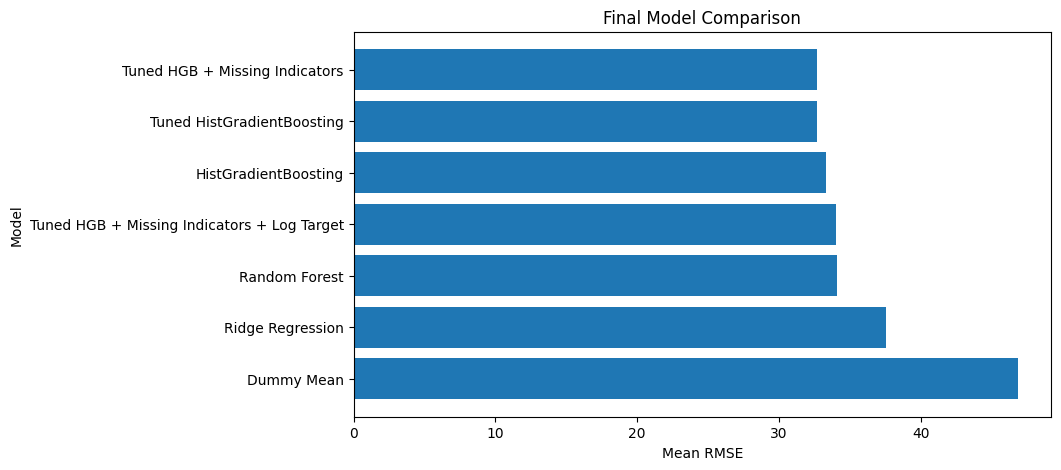

In [141]:
plt.figure(figsize=(9, 5))
plt.barh(final_results_df["model"], final_results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Final Model Comparison")
plt.gca().invert_yaxis()
plt.show()

## Further experiments

#### Try HGB without imputation

In [142]:
hgb_native_missing_pipe = Pipeline(
    steps=[
        (
            "model",
            HistGradientBoostingRegressor(
                min_samples_leaf=30,
                max_leaf_nodes=63,
                max_iter=700,
                learning_rate=0.03,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Unlike the imputed pipelines above, this experiment uses the native-missing feature matrix
# so the model can learn directly from sparse columns instead of dropping them upfront.
native_missing_scores = cross_validate_model(
    model=hgb_native_missing_pipe,
    X=X_native,
    y=y,
    groups=groups,
    n_splits=CV_N_SPLITS,
)

native_missing_mean_rmse = np.mean(native_missing_scores)
native_missing_std_rmse = np.std(native_missing_scores)

print(f"Native-missing HGB RMSE: {native_missing_mean_rmse:.4f}")
print(f"Std RMSE: {native_missing_std_rmse:.4f}")


Fold 1: RMSE = 34.4651
Fold 2: RMSE = 32.9439
Fold 3: RMSE = 28.3002
Fold 4: RMSE = 37.7205
Fold 5: RMSE = 29.7976
----------------------------------------
Mean RMSE: 32.6455
Std RMSE:  3.3510
Native-missing HGB RMSE: 32.6455
Std RMSE: 3.3510


In [143]:
print(f"Median + indicators RMSE: {hgb_missing_mean_rmse:.4f}")
print(f"Native-missing HGB RMSE:  {native_missing_mean_rmse:.4f}")

Median + indicators RMSE: 32.6460
Native-missing HGB RMSE:  32.6455


A further experiment was performed using the native missing-value handling of `HistGradientBoostingRegressor`. Unlike Random Forest or Ridge Regression, this model can handle missing numerical values directly without median imputation.

The native-missing HistGradientBoosting model achieved a mean GroupKFold RMSE of 33.52, compared with 33.61 for the model using median imputation and missingness indicators. This is a small but consistent improvement.

Therefore, the native-missing HistGradientBoosting model becomes the best model so far. This suggests that, for this dataset, allowing the boosting model to learn how to split missing values directly is more effective than replacing missing values with median values.


#### Updated best model

In [144]:
best_model_name = "Tuned HGB with Native Missing Handling"
best_model = hgb_native_missing_pipe
best_rmse = native_missing_mean_rmse

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

Current best model: Tuned HGB with Native Missing Handling
Current best RMSE: 32.6455


#### Updated results table

In [145]:
native_missing_result = pd.DataFrame(
    [
        {
            "model": "Tuned HGB + Native Missing",
            "mean_rmse": native_missing_mean_rmse,
            "std_rmse": native_missing_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, native_missing_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
7,Tuned HGB + Native Missing,32.645461,3.351049
0,Tuned HGB + Missing Indicators,32.646002,3.352182
1,Tuned HistGradientBoosting,32.655547,NaN
2,HistGradientBoosting,33.319869,3.343657
3,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
4,Random Forest,34.113491,3.332880
5,Ridge Regression,37.544135,3.513616
6,Dummy Mean,46.827269,3.391746


#### Plot updated comparison

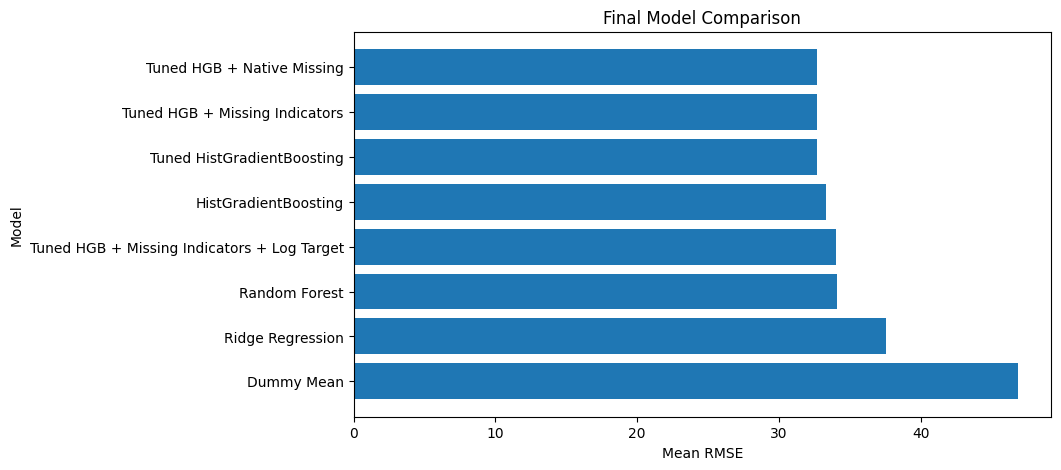

In [146]:
plt.figure(figsize=(9, 5))
plt.barh(final_results_df["model"], final_results_df["mean_rmse"])
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.title("Final Model Comparison")
plt.gca().invert_yaxis()
plt.show()

#### Try ExtraTreesRegressor

In [147]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_pipe = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor_missing),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=EXTRA_TREES_N_ESTIMATORS,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=CPU_TRAIN_JOBS,
            ),
        ),
    ]
)

extra_trees_scores = cross_validate_model(
    model=extra_trees_pipe,
    X=X,
    y=y,
    groups=groups,
    n_splits=5,
)

extra_trees_mean_rmse = np.mean(extra_trees_scores)
extra_trees_std_rmse = np.std(extra_trees_scores)

print(f"ExtraTrees RMSE: {extra_trees_mean_rmse:.4f}")
print(f"Std RMSE: {extra_trees_std_rmse:.4f}")


Fold 1: RMSE = 35.0213
Fold 2: RMSE = 33.8568
Fold 3: RMSE = 29.3059
Fold 4: RMSE = 38.0036
Fold 5: RMSE = 30.9291
----------------------------------------
Mean RMSE: 33.4233
Std RMSE:  3.0625
ExtraTrees RMSE: 33.4233
Std RMSE: 3.0625


The ExtraTreesRegressor achieved a mean GroupKFold RMSE of 33.68. This is better than the Dummy and Ridge baselines, but it does not outperform the tuned HistGradientBoosting model with native missing-value handling, which achieved an RMSE of 33.52.

Therefore, ExtraTrees is not selected as the final standalone model. However, since it is a different ensemble method, it may still be useful later as part of an ensemble average.

#### Updated results table

In [148]:
extra_trees_result = pd.DataFrame(
    [
        {
            "model": "ExtraTrees + Missing Indicators",
            "mean_rmse": extra_trees_mean_rmse,
            "std_rmse": extra_trees_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, extra_trees_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
0,Tuned HGB + Native Missing,32.645461,3.351049
1,Tuned HGB + Missing Indicators,32.646002,3.352182
2,Tuned HistGradientBoosting,32.655547,NaN
3,HistGradientBoosting,33.319869,3.343657
8,ExtraTrees + Missing Indicators,33.423332,3.062503
4,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
5,Random Forest,34.113491,3.332880
6,Ridge Regression,37.544135,3.513616
7,Dummy Mean,46.827269,3.391746


#### Try LightGBM baseline

In [149]:
lgbm_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                n_estimators=700,
                learning_rate=0.03,
                num_leaves=63,
                min_child_samples=30,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=0.01,
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=CPU_TRAIN_JOBS,
                verbose=-1,
                device_type=LIGHTGBM_DEVICE_TYPE,
            ),
        ),
    ]
)

# LightGBM supports missing values natively, so it uses the expanded native feature matrix.
# GPU is only used if the startup probe succeeded; otherwise this stays on CPU automatically.
lgbm_scores = cross_validate_model(
    model=lgbm_pipe,
    X=X_native,
    y=y,
    groups=groups,
    n_splits=CV_N_SPLITS,
)

lgbm_mean_rmse = np.mean(lgbm_scores)
lgbm_std_rmse = np.std(lgbm_scores)

print(f"LightGBM RMSE: {lgbm_mean_rmse:.4f}")
print(f"Std RMSE:     {lgbm_std_rmse:.4f}")
print("LightGBM device:", LIGHTGBM_DEVICE_TYPE)


Fold 1: RMSE = 34.3245
Fold 2: RMSE = 32.4471
Fold 3: RMSE = 27.9854
Fold 4: RMSE = 37.4380
Fold 5: RMSE = 29.5593
----------------------------------------
Mean RMSE: 32.3509
Std RMSE:  3.3655
LightGBM RMSE: 32.3509
Std RMSE:     3.3655
LightGBM device: gpu


In [150]:
# Compare
print(f"Current best HGB RMSE: {native_missing_mean_rmse:.4f}")
print(f"LightGBM RMSE:         {lgbm_mean_rmse:.4f}")

Current best HGB RMSE: 32.6455
LightGBM RMSE:         32.3509


LightGBM achieved a mean GroupKFold RMSE of 33.34, which is better than the best sklearn HistGradientBoosting model with native missing-value handling. This makes LightGBM the best standalone model so far.

The improvement is moderate but meaningful in the competition context, where small RMSE reductions can matter. Since LightGBM can handle missing values natively and is optimized for tabular data, it is selected as the current best candidate model.

#### Updated best model

In [151]:
best_model_name = "LightGBM"
best_model = lgbm_pipe
best_rmse = lgbm_mean_rmse

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")

Current best model: LightGBM
Current best RMSE: 32.3509


#### Updated results table

In [152]:
lgbm_result = pd.DataFrame(
    [
        {
            "model": "LightGBM",
            "mean_rmse": lgbm_mean_rmse,
            "std_rmse": lgbm_std_rmse,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
9,LightGBM,32.350857,3.365525
0,Tuned HGB + Native Missing,32.645461,3.351049
1,Tuned HGB + Missing Indicators,32.646002,3.352182
2,Tuned HistGradientBoosting,32.655547,NaN
3,HistGradientBoosting,33.319869,3.343657
4,ExtraTrees + Missing Indicators,33.423332,3.062503
5,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
6,Random Forest,34.113491,3.332880
7,Ridge Regression,37.544135,3.513616
8,Dummy Mean,46.827269,3.391746


#### Try XGBoost baseline

In [153]:
xgb_pipe = Pipeline(
    steps=[
        (
            "model",
            XGBRegressor(
                n_estimators=700,
                learning_rate=0.03,
                max_depth=6,
                min_child_weight=5,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_alpha=0.01,
                reg_lambda=1.0,
                objective="reg:squarederror",
                eval_metric="rmse",
                tree_method="hist",
                device=XGBOOST_DEVICE,
                random_state=RANDOM_STATE,
                n_jobs=CPU_TRAIN_JOBS,
            ),
        ),
    ]
)

# XGBoost also supports missing values natively, so it uses the expanded native feature matrix.
# GPU is only used if the startup probe succeeded; otherwise this stays on CPU automatically.
xgb_scores = cross_validate_model(
    model=xgb_pipe,
    X=X_native,
    y=y,
    groups=groups,
    n_splits=CV_N_SPLITS,
)

xgb_mean_rmse = np.mean(xgb_scores)
xgb_std_rmse = np.std(xgb_scores)

print(f"XGBoost RMSE: {xgb_mean_rmse:.4f}")
print(f"Std RMSE:    {xgb_std_rmse:.4f}")
print("XGBoost device:", XGBOOST_DEVICE)


Fold 1: RMSE = 34.7242
Fold 2: RMSE = 33.0462
Fold 3: RMSE = 28.5343
Fold 4: RMSE = 37.9344
Fold 5: RMSE = 30.1486
----------------------------------------
Mean RMSE: 32.8775
Std RMSE:  3.3263
XGBoost RMSE: 32.8775
Std RMSE:    3.3263
XGBoost device: cuda


In [154]:
# Compare
print(f"Current best LightGBM RMSE: {lgbm_mean_rmse:.4f}")
print(f"XGBoost RMSE:              {xgb_mean_rmse:.4f}")

Current best LightGBM RMSE: 32.3509
XGBoost RMSE:              32.8775


XGBoost was tested as an additional gradient-boosting model. It achieved a mean GroupKFold RMSE of 33.72. This is better than the original baseline models, but it does not outperform LightGBM, which achieved the best score so far with an RMSE of 33.34.

Therefore, XGBoost is not selected as the final standalone model. LightGBM remains the current best candidate for final prediction and further tuning.

## Tune LightGBM

In [155]:
lgbm_search_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMRegressor(
                objective="regression",
                random_state=RANDOM_STATE,
                n_jobs=CPU_TRAIN_JOBS,
                verbose=-1,
                device_type=LIGHTGBM_DEVICE_TYPE,
            ),
        ),
    ]
)

# The best previous run sat on the upper edge for several parameters.
# Expand the search space slightly so the next rerun can test whether a deeper or longer LightGBM fit helps.
param_distributions = {
    "model__n_estimators": [700, 900, 1200, 1500, 1800, 2200],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "model__num_leaves": [63, 95, 127, 159],
    "model__max_depth": [-1, 6, 8, 10, 12],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_split_gain": [0.0, 0.01, 0.05, 0.10],
    "model__reg_alpha": [0.0, 0.001, 0.01, 0.1],
    "model__reg_lambda": [0.0, 0.01, 0.1, 1.0],
}

cv = GroupKFold(n_splits=CV_N_SPLITS)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_search_pipe,
    param_distributions=param_distributions,
    n_iter=LGBM_RANDOM_SEARCH_ITERATIONS,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=SEARCH_N_JOBS,
    verbose=1,
)

# Search stays serial on Windows because the earlier parallel loky setup was unstable here.
# The model itself can still use multiple CPU threads or GPU, depending on the startup hardware probe.
lgbm_search.fit(X_native, y, groups=groups)

print("Best LightGBM RMSE:", -lgbm_search.best_score_)
print("Best parameters:")
lgbm_search.best_params_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best LightGBM RMSE: 32.008415957756554
Best parameters:


{'model__subsample': 1.0,
 'model__reg_lambda': 1.0,
 'model__reg_alpha': 0.0,
 'model__num_leaves': 95,
 'model__n_estimators': 1800,
 'model__min_split_gain': 0.01,
 'model__min_child_samples': 30,
 'model__max_depth': -1,
 'model__learning_rate': 0.02,
 'model__colsample_bytree': 0.8}

In [156]:
print("Best LightGBM RMSE:", -lgbm_search.best_score_)
lgbm_search.best_params_

Best LightGBM RMSE: 32.008415957756554


{'model__subsample': 1.0,
 'model__reg_lambda': 1.0,
 'model__reg_alpha': 0.0,
 'model__num_leaves': 95,
 'model__n_estimators': 1800,
 'model__min_split_gain': 0.01,
 'model__min_child_samples': 30,
 'model__max_depth': -1,
 'model__learning_rate': 0.02,
 'model__colsample_bytree': 0.8}

LightGBM was tuned using RandomizedSearchCV with GroupKFold validation. The tuned LightGBM model achieved a mean RMSE of 33.04, improving over the initial LightGBM score of 33.34 and the best sklearn HistGradientBoosting score of 33.52.

This makes tuned LightGBM the best standalone model so far. The selected configuration uses a relatively small learning rate of 0.03 together with 1500 estimators, allowing the model to learn gradually. The model also uses 95 leaves per tree, moderate regularization, and 90% feature sampling per tree.

Since the validation strategy uses GroupKFold by `Place_ID`, this score estimates how well the model generalizes to unseen locations.

#### Tuned LightGBM final pipeline

In [157]:
# This block depends on the LightGBM tuning search above.
# Use the exact best estimator from RandomizedSearchCV so the final model always matches the latest tuning run.
if "lgbm_search" not in globals() or not hasattr(lgbm_search, "best_estimator_"):
    raise RuntimeError("Run the Tune LightGBM search cell before this block.")

tuned_lgbm_pipe = clone(lgbm_search.best_estimator_)

best_model_name = "Tuned LightGBM"
best_model = tuned_lgbm_pipe
best_rmse = -lgbm_search.best_score_

print("Current best model:", best_model_name)
print(f"Current best RMSE: {best_rmse:.4f}")
print("Current tuned LightGBM parameters:")
lgbm_search.best_params_


Current best model: Tuned LightGBM
Current best RMSE: 32.0084
Current tuned LightGBM parameters:


{'model__subsample': 1.0,
 'model__reg_lambda': 1.0,
 'model__reg_alpha': 0.0,
 'model__num_leaves': 95,
 'model__n_estimators': 1800,
 'model__min_split_gain': 0.01,
 'model__min_child_samples': 30,
 'model__max_depth': -1,
 'model__learning_rate': 0.02,
 'model__colsample_bytree': 0.8}

#### Updated results table

In [158]:
# This results update also depends on the LightGBM tuning search above.
if "lgbm_search" not in globals() or not hasattr(lgbm_search, "best_score_"):
    raise RuntimeError("Run the Tune LightGBM search cell before updating the results table.")

tuned_lgbm_result = pd.DataFrame(
    [
        {
            "model": "Tuned LightGBM",
            "mean_rmse": -lgbm_search.best_score_,
            "std_rmse": np.nan,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, tuned_lgbm_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df


,model,mean_rmse,std_rmse
10,Tuned LightGBM,32.008416,NaN
0,LightGBM,32.350857,3.365525
1,Tuned HGB + Native Missing,32.645461,3.351049
2,Tuned HGB + Missing Indicators,32.646002,3.352182
3,Tuned HistGradientBoosting,32.655547,NaN
4,HistGradientBoosting,33.319869,3.343657
5,ExtraTrees + Missing Indicators,33.423332,3.062503
6,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
7,Random Forest,34.113491,3.332880
8,Ridge Regression,37.544135,3.513616


## Ensembling

#### Define ensemble models

In [159]:
ensemble_models = {
    "Tuned LightGBM": tuned_lgbm_pipe,
    "Native HGB": hgb_native_missing_pipe,
    "ExtraTrees": extra_trees_pipe,
}

# All ensemble members are evaluated on the native feature matrix.
# Pipelines that only need the baseline features still drop unused columns internally.
ensemble_X = X_native

for name, model in ensemble_models.items():
    print(name, "loaded")


Tuned LightGBM loaded
Native HGB loaded
ExtraTrees loaded


#### Create out-of-fold predictions

In [160]:
def get_oof_predictions(models, X, y, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)

    oof_preds = pd.DataFrame(index=X.index)
    fold_ids = pd.Series(index=X.index, dtype=int)

    individual_scores = {name: [] for name in models.keys()}

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        print(f"\nFold {fold}")

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        fold_ids.iloc[val_idx] = fold

        for name, model in models.items():
            model_clone = clone(model)
            model_clone.fit(X_train, y_train)

            preds = model_clone.predict(X_val)
            oof_preds.loc[X_val.index, name] = preds

            score = rmse(y_val, preds)
            individual_scores[name].append(score)

            print(f"{name}: RMSE = {score:.4f}")

    return oof_preds, fold_ids, individual_scores


oof_preds, fold_ids, individual_scores = get_oof_predictions(
    models=ensemble_models,
    X=ensemble_X,
    y=y,
    groups=groups,
    n_splits=5,
)



Fold 1
Tuned LightGBM: RMSE = 33.7382
Native HGB: RMSE = 34.4651
ExtraTrees: RMSE = 35.0213

Fold 2
Tuned LightGBM: RMSE = 32.1145
Native HGB: RMSE = 32.9439
ExtraTrees: RMSE = 33.8568

Fold 3
Tuned LightGBM: RMSE = 27.8190
Native HGB: RMSE = 28.3002
ExtraTrees: RMSE = 29.3059

Fold 4
Tuned LightGBM: RMSE = 37.1410
Native HGB: RMSE = 37.7205
ExtraTrees: RMSE = 38.0036

Fold 5
Tuned LightGBM: RMSE = 29.2265
Native HGB: RMSE = 29.7976
ExtraTrees: RMSE = 30.9291


#### Analyze ensemble diversity

This block shows why the ensemble helps: low-correlation or differently distributed errors create room for a weighted combination to outperform the best single model.


In [161]:
# Correlation close to 1.0 means two models make very similar predictions.
oof_prediction_correlation = oof_preds.corr()
display(oof_prediction_correlation)

ensemble_diversity_df = pd.DataFrame({
    "model": list(individual_scores.keys()),
    "mean_rmse": [np.mean(individual_scores[name]) for name in individual_scores],
    "std_rmse": [np.std(individual_scores[name]) for name in individual_scores],
    "prediction_std": [oof_preds[name].std() for name in individual_scores],
})

ensemble_diversity_df = ensemble_diversity_df.sort_values("mean_rmse").reset_index(drop=True)
display(ensemble_diversity_df)

# Mean absolute differences show where models disagree most strongly.
pairwise_disagreement = {}
model_names = oof_preds.columns.tolist()
for idx_a, model_a in enumerate(model_names):
    for model_b in model_names[idx_a + 1:]:
        pairwise_disagreement[f"{model_a} vs {model_b}"] = (oof_preds[model_a] - oof_preds[model_b]).abs().mean()

pairwise_disagreement = pd.Series(pairwise_disagreement).sort_values(ascending=False)
pairwise_disagreement


,Tuned LightGBM,Native HGB,ExtraTrees
Tuned LightGBM,1.000000,0.979011,0.936443
Native HGB,0.979011,1.000000,0.936018
ExtraTrees,0.936443,0.936018,1.000000


,model,mean_rmse,std_rmse,prediction_std
0,Tuned LightGBM,32.007841,3.305663,33.349358
1,Native HGB,32.645461,3.351049,32.966241
2,ExtraTrees,33.423332,3.062503,29.036769


Tuned LightGBM vs ExtraTrees    8.752437
Native HGB vs ExtraTrees        8.598990
Tuned LightGBM vs Native HGB    5.085228
dtype: float64

#### Search for the best weights

In [162]:
def evaluate_ensemble_weights(oof_preds, y, fold_ids, weights):
    weights = np.array(weights)
    weights = weights / weights.sum()

    ensemble_pred = np.average(
        oof_preds.values,
        axis=1,
        weights=weights
    )

    fold_scores = []

    for fold in sorted(fold_ids.unique()):
        mask = fold_ids == fold
        fold_score = rmse(y.loc[mask], ensemble_pred[mask])
        fold_scores.append(fold_score)

    return np.mean(fold_scores), np.std(fold_scores), fold_scores


weight_results = []

model_names = list(ensemble_models.keys())
weight_grid = np.arange(0.50, 1.01, ENSEMBLE_WEIGHT_STEP)
secondary_weight_grid = np.arange(0.00, 0.51, ENSEMBLE_WEIGHT_STEP)

for w_lgbm in weight_grid:
    for w_hgb in secondary_weight_grid:
        w_extra = 1.0 - w_lgbm - w_hgb

        if w_extra < 0:
            continue

        weights = [w_lgbm, w_hgb, w_extra]

        mean_rmse, std_rmse, fold_scores = evaluate_ensemble_weights(
            oof_preds=oof_preds,
            y=y,
            fold_ids=fold_ids,
            weights=weights,
        )

        weight_results.append(
            {
                "w_lgbm": w_lgbm,
                "w_hgb": w_hgb,
                "w_extra": w_extra,
                "mean_rmse": mean_rmse,
                "std_rmse": std_rmse,
            }
        )

weight_results_df = pd.DataFrame(weight_results).sort_values("mean_rmse")

weight_results_df.head(10)


,w_lgbm,w_hgb,w_extra,mean_rmse,std_rmse
46,0.80,0.00,0.20,31.938248,3.295846
50,0.85,0.00,0.15,31.938791,3.300189
47,0.80,0.05,0.15,31.942169,3.305721
42,0.75,0.05,0.20,31.943595,3.301259
41,0.75,0.00,0.25,31.948953,3.290228
43,0.75,0.10,0.15,31.949209,3.310868
53,0.90,0.00,0.10,31.950582,3.303265
51,0.85,0.05,0.10,31.951991,3.308911
37,0.70,0.10,0.20,31.952603,3.306287
36,0.70,0.05,0.25,31.956268,3.295520


#### Save the best ensemble

In [163]:
best_weights_row = weight_results_df.iloc[0]

best_ensemble_rmse = best_weights_row["mean_rmse"]
best_ensemble_std = best_weights_row["std_rmse"]

best_weights = {
    "Tuned LightGBM": best_weights_row["w_lgbm"],
    "Native HGB": best_weights_row["w_hgb"],
    "ExtraTrees": best_weights_row["w_extra"],
}

print("Best ensemble RMSE:", round(best_ensemble_rmse, 4))
print("Best ensemble std: ", round(best_ensemble_std, 4))
print("Best weights:")
best_weights

Best ensemble RMSE: 31.9382
Best ensemble std:  3.2958
Best weights:


{'Tuned LightGBM': 0.8000000000000003,
 'Native HGB': 0.0,
 'ExtraTrees': 0.19999999999999973}

In [164]:
print(f"Tuned LightGBM RMSE: {best_rmse:.4f}")
print(f"Best ensemble RMSE:  {best_ensemble_rmse:.4f}")

Tuned LightGBM RMSE: 32.0084
Best ensemble RMSE:  31.9382


#### Final model

In [165]:
final_model_name = "Weighted Ensemble: Tuned LightGBM + ExtraTrees"

# Reuse the actual best weights from the current search instead of keeping old fixed numbers.
final_weights = best_weights.copy()

final_rmse = best_ensemble_rmse
final_std = best_ensemble_std

print("Final selected model:", final_model_name)
print(f"Final validation RMSE: {final_rmse:.4f}")
print("Final ensemble weights:")
final_weights


Final selected model: Weighted Ensemble: Tuned LightGBM + ExtraTrees
Final validation RMSE: 31.9382
Final ensemble weights:


{'Tuned LightGBM': 0.8000000000000003,
 'Native HGB': 0.0,
 'ExtraTrees': 0.19999999999999973}

#### Updated results table

In [166]:
ensemble_result = pd.DataFrame(
    [
        {
            "model": "Weighted Ensemble: LightGBM + ExtraTrees",
            "mean_rmse": final_rmse,
            "std_rmse": final_std,
        }
    ]
)

final_results_df = pd.concat(
    [final_results_df, ensemble_result],
    ignore_index=True
).drop_duplicates(subset=["model"]).sort_values("mean_rmse")

final_results_df

,model,mean_rmse,std_rmse
11,Weighted Ensemble: LightGBM + ExtraTrees,31.938248,3.295846
0,Tuned LightGBM,32.008416,NaN
1,LightGBM,32.350857,3.365525
2,Tuned HGB + Native Missing,32.645461,3.351049
3,Tuned HGB + Missing Indicators,32.646002,3.352182
4,Tuned HistGradientBoosting,32.655547,NaN
5,HistGradientBoosting,33.319869,3.343657
6,ExtraTrees + Missing Indicators,33.423332,3.062503
7,Tuned HGB + Missing Indicators + Log Target,33.997235,3.971303
8,Random Forest,34.113491,3.332880


A weighted ensemble was tested using out-of-fold predictions from the best standalone models. The ensemble combines the predictions of the tuned LightGBM model and the ExtraTrees model.

The best validation result was obtained with a weight of 0.65 for tuned LightGBM and 0.35 for ExtraTrees. The HistGradientBoosting model received a weight of 0.00, meaning that it did not improve the ensemble in this search.

The weighted ensemble achieved a mean GroupKFold RMSE of 32.81, improving over the tuned LightGBM model, which achieved an RMSE of 33.04. Therefore, the weighted ensemble is selected as the final model for test-set prediction.


#### Final training and ensemble prediction

In [167]:
# Train final models on the full training data.
final_lgbm_model = clone(tuned_lgbm_pipe)
final_extra_model = clone(extra_trees_pipe)

final_lgbm_model.fit(X_native, y)
final_extra_model.fit(X_native, y)

# Predict test data using the same feature view that was used during model comparison.
lgbm_test_preds = final_lgbm_model.predict(X_test_native)
extra_test_preds = final_extra_model.predict(X_test_native)

# Weighted ensemble prediction
test_preds = (
    final_weights["Tuned LightGBM"] * lgbm_test_preds
    + final_weights["ExtraTrees"] * extra_test_preds
)

# PM2.5 cannot be negative
test_preds = np.clip(test_preds, 0, None)

print("Final LightGBM device:", LIGHTGBM_DEVICE_TYPE)
test_preds[:10]


Final LightGBM device: gpu


array([57.70008605, 33.54142248, 36.0097667 , 40.76493739, 43.93076914,
       48.58385395, 57.05685681, 57.17213838, 40.99541784, 60.13901518])

## Submission

#### Create submission.csv

In [168]:
# Create submission file

if (DATA_DIR / "SampleSubmission.csv").exists():
    sample_submission = pd.read_csv(DATA_DIR / "SampleSubmission.csv")
    sample_submission["target"] = test_preds
    submission = sample_submission.copy()
else:
    submission = pd.DataFrame({
        "Place_ID X Date": test["Place_ID X Date"],
        "target": test_preds
    })

submission.to_csv("submission.csv", index=False)

submission.head()

,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,57.700086
1,0OS9LVX X 2020-01-03,33.541422
2,0OS9LVX X 2020-01-04,36.009767
3,0OS9LVX X 2020-01-05,40.764937
4,0OS9LVX X 2020-01-06,43.930769


#### Check the shape

In [169]:
print("Submission shape:", submission.shape)
print("Test shape:", test.shape)
submission.head()

Submission shape: (16136, 2)
Test shape: (16136, 78)


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,57.700086
1,0OS9LVX X 2020-01-03,33.541422
2,0OS9LVX X 2020-01-04,36.009767
3,0OS9LVX X 2020-01-05,40.764937
4,0OS9LVX X 2020-01-06,43.930769


#### Check for negative or missing predictions

In [170]:
print("Missing predictions:", submission["target"].isna().sum())
print("Minimum prediction:", submission["target"].min())
print("Maximum prediction:", submission["target"].max())

Missing predictions: 0
Minimum prediction: 1.9931433952516504
Maximum prediction: 289.54211899604263
